In [10]:
!pip install pandas pydicom -q
!pip install torch torchvision -q
!pip install monai[all] pandas pydicom scikit-learn tqdm -q


[notice] A new release of pip available: 22.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip available: 22.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df_orig_train = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')

In [3]:
df_orig_train

,SeriesInstanceUID,PatientAge,PatientSex,Modality,Left Infraclinoid Internal Carotid Artery,Right Infraclinoid Internal Carotid Artery,Left Supraclinoid Internal Carotid Artery,Right Supraclinoid Internal Carotid Artery,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,1.2.826.0.1.3680043.8.498.10004044428023505108...,64,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1.2.826.0.1.3680043.8.498.10004684224894397679...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.8.498.10005158603912009425...,58,Male,CTA,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,1.2.826.0.1.3680043.8.498.10009383108068795488...,71,Male,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1.2.826.0.1.3680043.8.498.10012790035410518400...,48,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4400,1.2.826.0.1.3680043.8.498.99915610493694667606...,62,Female,MRI T1post,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4401,1.2.826.0.1.3680043.8.498.99920680741054836990...,76,Female,MRA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4402,1.2.826.0.1.3680043.8.498.99953513260518059135...,44,Female,CTA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4403,1.2.826.0.1.3680043.8.498.99982144859397209076...,58,Female,MRI T2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
for x in df_orig_train.columns:
    print(df_orig_train[x].value_counts())
    print(df_orig_train[x].isnull().sum())
    print('*'*50)

SeriesInstanceUID
1.2.826.0.1.3680043.8.498.99985209798463601651869595532975221005    1
1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647    1
1.2.826.0.1.3680043.8.498.10004684224894397679901841656954650085    1
1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317    1
1.2.826.0.1.3680043.8.498.10009383108068795488741533244914370182    1
                                                                   ..
1.2.826.0.1.3680043.8.498.10023411164590664678534044036963716636    1
1.2.826.0.1.3680043.8.498.10022796280698534221758473208024838831    1
1.2.826.0.1.3680043.8.498.10022688097731894079510930966432818105    1
1.2.826.0.1.3680043.8.498.10021411248005513321236647460239137906    1
1.2.826.0.1.3680043.8.498.10014757658335054766479957992112625961    1
Name: count, Length: 4405, dtype: int64
0
**************************************************
PatientAge
55    127
68    126
65    126
63    125
60    120
     ... 
22     17
21     16
23     13
24     12
18     1

<Axes: xlabel='PatientAge', ylabel='Count'>

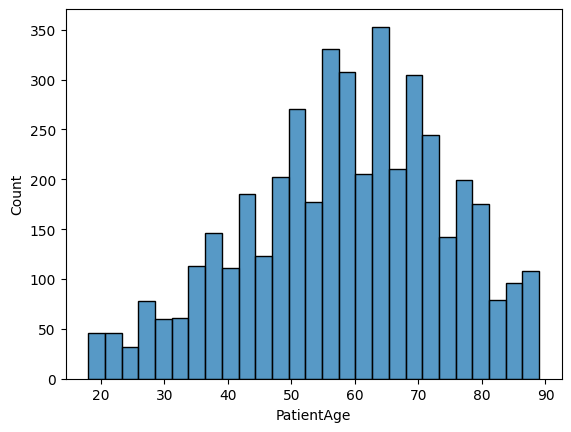

In [4]:
sns.histplot(df_orig_train['PatientAge'])

In [14]:
df_orig_train['Modality'].value_counts()

Modality
CTA           1857
MRA           1256
MRI T2         986
MRI T1post     306
Name: count, dtype: int64

In [20]:
df_orig_train.dtypes

SeriesInstanceUID                             object
PatientAge                                     int64
PatientSex                                    object
Modality                                      object
Left Infraclinoid Internal Carotid Artery      int64
Right Infraclinoid Internal Carotid Artery     int64
Left Supraclinoid Internal Carotid Artery      int64
Right Supraclinoid Internal Carotid Artery     int64
Left Middle Cerebral Artery                    int64
Right Middle Cerebral Artery                   int64
Anterior Communicating Artery                  int64
Left Anterior Cerebral Artery                  int64
Right Anterior Cerebral Artery                 int64
Left Posterior Communicating Artery            int64
Right Posterior Communicating Artery           int64
Basilar Tip                                    int64
Other Posterior Circulation                    int64
Aneurysm Present                               int64
dtype: object

In [26]:
for col in df_orig_train.columns:
    if df_orig_train[col].dtype != 'int64':
        continue
    print(f'{col}: {df_orig_train[col].sum()}')
    print('*'*50)

PatientAge: 257552
**************************************************
Left Infraclinoid Internal Carotid Artery: 79
**************************************************
Right Infraclinoid Internal Carotid Artery: 99
**************************************************
Left Supraclinoid Internal Carotid Artery: 340
**************************************************
Right Supraclinoid Internal Carotid Artery: 282
**************************************************
Left Middle Cerebral Artery: 220
**************************************************
Right Middle Cerebral Artery: 299
**************************************************
Anterior Communicating Artery: 366
**************************************************
Left Anterior Cerebral Artery: 46
**************************************************
Right Anterior Cerebral Artery: 56
**************************************************
Left Posterior Communicating Artery: 87
**************************************************
Right Posterior Commu

In [7]:
import pydicom

# Load the DICOM file
dcm_path = r"C:\Users\solan\Downloads\1.2.826.0.1.3680043.8.498.12512789258062887712849260043950985853.dcm"
ds = pydicom.dcmread(dcm_path)

# Print all metadata tags with their name and value
for elem in ds.iterall():
    print(f"{elem.tag} | {elem.keyword:35} | {repr(elem.value)[:80]}")


(0008,0005) | SpecificCharacterSet                | 'ISO_IR 100'
(0008,0008) | ImageType                           | ['ORIGINAL', 'PRIMARY', 'TOF', 'NONE']
(0008,0016) | SOPClassUID                         | '1.2.840.10008.5.1.4.1.1.4.1'
(0008,0018) | SOPInstanceUID                      | '1.2.826.0.1.3680043.8.498.12512789258062887712849260043950985853'
(0008,0020) | StudyDate                           | '20340307'
(0008,0021) | SeriesDate                          | '20340307'
(0008,0023) | ContentDate                         | '20340307'
(0008,002A) | AcquisitionDateTime                 | '20000101'
(0008,0030) | StudyTime                           | '195521'
(0008,0031) | SeriesTime                          | '200254.15000'
(0008,0033) | ContentTime                         | '200254.15000'
(0008,0050) | AccessionNumber                     | '179'
(0008,0060) | Modality                            | 'MR'
(0008,0070) | Manufacturer                        | 'Philips Medical Systems'
(00

In [2]:
selected_feat = [
    # --- Identifiers ---
    'StudyInstanceUID',
    'SeriesInstanceUID',     # You had this
    'SOPInstanceUID',        # You had this
    'PatientID',

    # --- Patient Info ---
    'PatientAge',
    'PatientSex',
    'PatientWeight',         # You had this
    'PatientSize',           # You had this
    'EthnicGroup',           # You had this
    'SmokingStatus',         # You had this

    # --- Study & Series Descriptors ---
    'Modality',              # You had this
    'StudyDescription',      # You had this
    'SeriesDescription',
    'BodyPartExamined',      # You had this
    'MRAcquisitionType',
    'AngioFlag',

    # --- Image Geometry (CRITICAL for 3D) ---
    'Rows',
    'Columns',
    'PixelSpacing',
    'SliceThickness',
    'SpacingBetweenSlices',
    'ImagePositionPatient',
    'ImageOrientationPatient',

    # --- Acquisition Parameters (Affects image appearance) ---
    'RepetitionTime',
    'EchoTime',
    'FlipAngle',
    'MagneticFieldStrength',
    'Manufacturer',
    'ManufacturerModelName',
    'ScanningSequence',

    # --- Pixel & Windowing Info (For data loading) ---
    'BitsAllocated',
    'BitsStored',
    'PixelRepresentation',
    'WindowCenter',
    'WindowWidth',
    'RescaleIntercept',      # Important to include, will be None for MR but critical for CT
    'RescaleSlope',           # Same as above

    'NumberOfFrames'
]

In [3]:
def extract_dicom_metadata(dcm_path=None, dcm_file=None):
    if dcm_file is None:
        ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
    else:
        ds = dcm_file
    extracted_data = {}

    for tag in selected_feat:
        value = getattr(ds, tag, None)
        if isinstance(value, pydicom.multival.MultiValue):
            value = list(value)
        extracted_data[tag] = value

    return extracted_data

In [4]:
import time

In [8]:
st = time.time()
extract_dicom_metadata(dcm_path)
print(time.time()-st)

0.0021715164184570312


In [9]:
import os

In [10]:
dicom_base_path = r"rsna-intracranial-aneurysm-detection\series"

all_dcm_patth_list =[]
for dirpath, dirnames, filenames in os.walk(dicom_base_path):
    # print(dirpath)
    # print(dirnames)
    # print(filenames)
    # print('*'*50)

    for filename in filenames:
        dcm_path = os.path.join(dirpath, filename)
        all_dcm_patth_list.append(dcm_path)

        

In [11]:
len(all_dcm_patth_list)

1012263

In [23]:
all_f_ext =  [x[-4:] for x in all_dcm_patth_list]

In [24]:
pd.DataFrame(all_f_ext).value_counts()

0   
.dcm    1012263
Name: count, dtype: int64

In [ ]:
metadata_dict_list =[]

for i,x in enumerate(all_dcm_patth_list):
    metadata_dict_list.append(extract_dicom_metadata(x))
    print(f'{i}/1012263')

In [ ]:
pd.DataFrame(metadata_dict_list).isna

In [18]:
metadata_df = pd.DataFrame(metadata_dict_list)

In [19]:
metadata_df

,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,PatientID,PatientAge,PatientSex,PatientWeight,PatientSize,EthnicGroup,SmokingStatus,...,ManufacturerModelName,ScanningSequence,BitsAllocated,BitsStored,PixelRepresentation,WindowCenter,WindowWidth,RescaleIntercept,RescaleSlope,NumberOfFrames
0,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10124807242473374136...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10138383895715496920...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10163629202066490350...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10168500191766317056...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10229246287448303586...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,UNKNOWN,...,Aera,GR,16,16,1,297.0,628.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012258,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.95879899683763729350...,af4d0d71-726,None,O,NaN,NaN,None,None,...,SOMATOM Perspective,None,16,16,1,"[80, 250]","[700, 500]",-1024.0,1.0,NaN
1012259,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.97165057246223213383...,af4d0d71-726,None,O,NaN,NaN,None,None,...,SOMATOM Perspective,None,16,16,1,"[80, 250]","[700, 500]",-1024.0,1.0,NaN
1012260,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.98211094707915345512...,af4d0d71-726,None,O,NaN,NaN,None,None,...,SOMATOM Perspective,None,16,16,1,"[80, 250]","[700, 500]",-1024.0,1.0,NaN
1012261,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.98435337720565769477...,af4d0d71-726,None,O,NaN,NaN,None,None,...,SOMATOM Perspective,None,16,16,1,"[80, 250]","[700, 500]",-1024.0,1.0,NaN


In [20]:
metadata_df.to_csv('metadata_df.csv')

In [3]:
metadata_df = pd.read_csv('metadata_df.csv')

C:\Users\solan\AppData\Local\Temp\ipykernel_20392\88472766.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv('metadata_df.csv')


In [5]:
metadata_df.shape

(1012263, 39)

In [4]:
for x in metadata_df.columns:
    print(metadata_df[x].value_counts())
    print(metadata_df[x].isnull().sum())
    print('*'*50)

Unnamed: 0
1012262    1
0          1
1          1
2          1
3          1
          ..
11         1
10         1
9          1
8          1
7          1
Name: count, Length: 1012263, dtype: int64
0
**************************************************
StudyInstanceUID
1.2.826.0.1.3680043.8.498.26875275827756142632463662271305814995    1441
1.2.826.0.1.3680043.8.498.95823759726018881810909243809398453285    1331
1.2.826.0.1.3680043.8.498.54090196673781955332780103653722908665    1314
1.2.826.0.1.3680043.8.498.96493458432292738336891549465693531362    1311
1.2.826.0.1.3680043.8.498.90287698646889729761534522929777327309    1291
                                                                    ... 
1.2.826.0.1.3680043.8.498.10034385894802321175291320093789615030       1
1.2.826.0.1.3680043.8.498.95814811312894040378383764209574694874       1
1.2.826.0.1.3680043.8.498.11035097333885684808818474949068969433       1
1.2.826.0.1.3680043.8.498.11819620448760534150797658408275744970       1
1.2

In [12]:
df_concat = pd.merge(metadata_df,df_orig_train, how='left', on='SeriesInstanceUID')

In [13]:
df_concat

,Unnamed: 0,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,PatientID,PatientAge_x,PatientSex_x,PatientWeight,PatientSize,EthnicGroup,...,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
0,0,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10124807242473374136...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
1,1,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10138383895715496920...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
2,2,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10163629202066490350...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
3,3,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10168500191766317056...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
4,4,1.2.826.0.1.3680043.8.498.39748519923130402194...,1.2.826.0.1.3680043.8.498.10004044428023505108...,1.2.826.0.1.3680043.8.498.10229246287448303586...,76dc135c-f3d,065Y,F,71.6,1.676,Not Hispanic/Lat,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1012258,1012258,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.95879899683763729350...,af4d0d71-726,NaN,O,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,1
1012259,1012259,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.97165057246223213383...,af4d0d71-726,NaN,O,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,1
1012260,1012260,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.98211094707915345512...,af4d0d71-726,NaN,O,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,1
1012261,1012261,1.2.826.0.1.3680043.8.498.12076725848021974954...,1.2.826.0.1.3680043.8.498.99985209798463601651...,1.2.826.0.1.3680043.8.498.98435337720565769477...,af4d0d71-726,NaN,O,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,1


In [14]:
df_concat.to_csv('df_concat.csv')

In [16]:
df_concat.shape

(1012263, 56)

In [ ]:
for x in df_concat.columns:
    print(df_concat[x].value_counts())
    print(df_concat[x].isnull().sum())
    print('*'*50)

Unnamed: 0
1012262    1
0          1
1          1
2          1
3          1
          ..
11         1
10         1
9          1
8          1
7          1
Name: count, Length: 1012263, dtype: int64
0
**************************************************
StudyInstanceUID
1.2.826.0.1.3680043.8.498.26875275827756142632463662271305814995    1441
1.2.826.0.1.3680043.8.498.95823759726018881810909243809398453285    1331
1.2.826.0.1.3680043.8.498.54090196673781955332780103653722908665    1314
1.2.826.0.1.3680043.8.498.96493458432292738336891549465693531362    1311
1.2.826.0.1.3680043.8.498.90287698646889729761534522929777327309    1291
                                                                    ... 
1.2.826.0.1.3680043.8.498.10034385894802321175291320093789615030       1
1.2.826.0.1.3680043.8.498.95814811312894040378383764209574694874       1
1.2.826.0.1.3680043.8.498.11035097333885684808818474949068969433       1
1.2.826.0.1.3680043.8.498.11819620448760534150797658408275744970       1
1.2

<Axes: xlabel='Rows', ylabel='Count'>

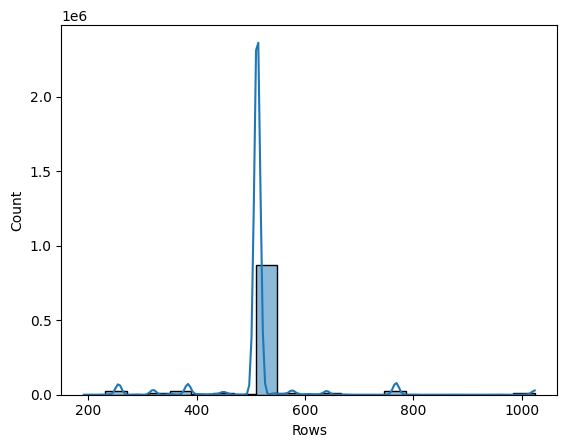

In [19]:
sns.histplot(df_concat['Rows'],kde=True)   

<Axes: xlabel='Columns', ylabel='Count'>

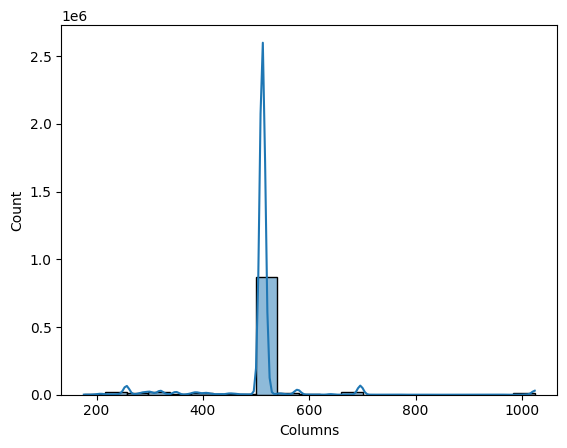

In [20]:
sns.histplot(df_concat['Columns'],kde=True)   

In [69]:
df_concat = pd.read_csv('df_concat.csv')

C:\Users\solan\AppData\Local\Temp\ipykernel_11836\2222918521.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_concat = pd.read_csv('df_concat.csv')


In [70]:
df_ct = df_concat[df_concat['Modality_x'] == 'CT'].copy()
df_mr = df_concat[df_concat['Modality_x'] == 'MR'].copy()

In [6]:
df_ct.shape

(737104, 57)

In [210]:
for x in df_ct.columns:
    print(df_ct[x].value_counts())
    print(f'null count = {df_ct[x].isnull().sum()}')
    print('*'*50)

Unnamed: 0.1
1012246    1
1012245    1
1012244    1
1012243    1
1012242    1
          ..
339        1
338        1
337        1
336        1
335        1
Name: count, Length: 737104, dtype: int64
null count = 0
**************************************************
Unnamed: 0
1012246    1
1012245    1
1012244    1
1012243    1
1012242    1
          ..
339        1
338        1
337        1
336        1
335        1
Name: count, Length: 737104, dtype: int64
null count = 0
**************************************************
StudyInstanceUID
1.2.826.0.1.3680043.8.498.26875275827756142632463662271305814995    1441
1.2.826.0.1.3680043.8.498.95823759726018881810909243809398453285    1331
1.2.826.0.1.3680043.8.498.54090196673781955332780103653722908665    1314
1.2.826.0.1.3680043.8.498.96493458432292738336891549465693531362    1311
1.2.826.0.1.3680043.8.498.90287698646889729761534522929777327309    1291
                                                                    ... 
1.2.826.0.1.3680043

In [7]:
df_mr.shape

(275159, 57)

In [8]:
print(df_ct['RescaleIntercept'].isnull().sum())
df_ct['RescaleSlope'].value_counts()

377593


RescaleSlope
1.0     352138
10.0      7373
Name: count, dtype: int64

In [9]:
print(df_mr['RescaleIntercept'].isnull().sum())
df_mr['RescaleSlope'].value_counts()

235177


RescaleSlope
1.0    39982
Name: count, dtype: int64

In [10]:
df_ct[df_ct['RescaleIntercept'].isnull()]['Modality_y'].value_counts()

Modality_y
CTA    377593
Name: count, dtype: int64

In [ ]:
df_ct

In [113]:
import pydicom
import numpy as np

def robust_hu_conversion(dicom_dataset):
    pixel_array = dicom_dataset.pixel_array
    
    if 'RescaleSlope' in dicom_dataset and 'RescaleIntercept' in dicom_dataset:
        slope = float(dicom_dataset.RescaleSlope)
        intercept = float(dicom_dataset.RescaleIntercept)
        return (pixel_array * slope) + intercept

        if pixel_array.min() < -500 or False:
            return pixel_array
        else:
            print('converting to hu')
            return (pixel_array * slope) + intercept
            
    else:
        return pixel_array

In [12]:
base_path = r"rsna-intracranial-aneurysm-detection\series"

In [13]:
import os

In [14]:
dir_path = os.path.join(base_path, df_ct.iloc[0]['SeriesInstanceUID'])
file_dir = [os.path.join(dir_path, f) for f in os.listdir(dir_path)]

In [15]:
pixel_arrays = []
for file_path in file_dir:
    pixel_array = robust_hu_conversion(pydicom.dcmread(file_path))
    pixel_arrays.append(pixel_array)

In [16]:
pixel_arrays

[array([[ -986,  -986,  -987, ...,  -995, -1002, -1005],
        [ -994,  -993,  -992, ..., -1004, -1007, -1008],
        [-1007, -1002,  -999, ..., -1010, -1011, -1007],
        ...,
        [ -913,  -920,  -928, ...,  -933,  -942,  -952],
        [ -895,  -913,  -930, ...,  -930,  -937,  -945],
        [ -861,  -891,  -918, ...,  -933,  -939,  -943]],
       shape=(512, 512), dtype=int16),
 array([[-988, -990, -993, ..., -991, -988, -987],
        [-990, -989, -989, ..., -991, -988, -988],
        [-994, -990, -987, ..., -992, -992, -994],
        ...,
        [-932, -942, -947, ..., -977, -976, -978],
        [-888, -912, -928, ..., -963, -962, -964],
        [-815, -852, -881, ..., -945, -946, -952]],
       shape=(512, 512), dtype=int16),
 array([[-1004, -1003,  -999, ...,  -996,  -992,  -991],
        [-1004, -1003, -1001, ...,  -998,  -993,  -990],
        [-1007, -1005, -1002, ..., -1000,  -995,  -992],
        ...,
        [ -922,  -935,  -943, ...,  -943,  -949,  -951],
     

In [17]:
df_mr.iloc[0]['SeriesInstanceUID']

'1.2.826.0.1.3680043.8.498.10004044428023505108375152878107656647'

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def apply_window(hu_image, min_value, max_value):
    """Applies a window to an HU image to make it viewable."""
    # min_value = window_center - window_width / 2
    # max_value = window_center + window_width / 2
    
    # Clip the image to the window range
    windowed_image = np.clip(hu_image, min_value, max_value)
    
    return windowed_image

def apply_mask(hu_image, min_val, max_val,fill_value=0):
    mask = (hu_image > min_val) & (hu_image < max_val)
    return np.where(mask, hu_image, fill_value)

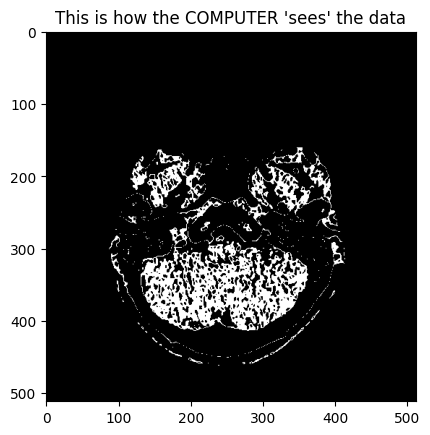

In [70]:
# Keep only the pixels that are likely to be contrast-filled vessels or bone
vessel_mask = (pixel_arrays[18] > 40) & (pixel_arrays[18] < 80)

# This creates a black and white image where only the vessels are white
plt.imshow(vessel_mask, cmap='gray')
plt.title("This is how the COMPUTER 'sees' the data")
plt.show()

In [21]:
!pip install monai numpy pydicom -q


[notice] A new release of pip available: 22.2.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import os
import torch
import numpy as np
import pydicom
from monai.transforms import (
    Compose,
    LoadImageD,        # This transform now handles adding the channel
    Lambdad,
    SpacingD,
    OrientationD,
    ScaleIntensityRangeD,
    ResizeD,
    EnsureTyped
)

# --- This function remains the same ---
def robust_hu_conversion(dicom_dataset):
    pixel_array = dicom_dataset.pixel_array
    
    if 'RescaleSlope' in dicom_dataset and 'RescaleIntercept' in dicom_dataset:
        slope = float(dicom_dataset.RescaleSlope)
        intercept = float(dicom_dataset.RescaleIntercept)
        print('tsdyfg')
        return (pixel_array * slope) + intercept

        if pixel_array.min() < -500 or pixel_array.min() == -2000:
            return pixel_array
        else:
            return (pixel_array * slope) + intercept
            
    else:
        return pixel_array

def create_preprocessing_pipeline(
    target_spacing=(1.0, 1.0, 1.0),
    target_orientation="LPS",
    clip_min=-200,
    clip_max=1000,
    scale_min=0.0,
    scale_max=1.0,
    target_spatial_size=(256, 256, 128)
):
    """
    Creates a MONAI preprocessing pipeline with exposed parameters.
    """
    
    transforms = [
        # --- Step 1: Load Image & Add Channel ---
        # It now does two things:
        # 1. Loads all DICOM files from the list of paths.
        # 2. Stacks them into a 3D volume.
        # 3. Automatically adds a "channel" dimension at the beginning.
        # The output shape will be (1, H, W, D) - Channel, Height, Width, Depth
        LoadImageD(keys=["image"], image_only=False),
        
        # --- Step 2: Custom Robust HU Conversion ---
        # The 'Lambdad' transform is a wrapper that lets us apply our own custom
        # Python function to the data. It receives the image object from LoadImageD,
        # which contains both the pixel data (.get_array()) and the metadata (.meta).
        Lambdad(keys=["image"], func=lambda x: robust_hu_conversion(x.get_array(), x.meta)),
        
        # --- Step 3: Isotropic Resampling ---
        # This is SpacingD. It looks at the metadata to find the *current* voxel
        # spacing (e.g., 0.5mm, 0.5mm, 1.25mm) and uses interpolation to create a
        # *new* volume where the spacing is the `target_spacing` (e.g., 1mm, 1mm, 1mm).
        # This makes all voxels cubic, which is crucial for 3D CNNs.
        SpacingD(
            keys=["image"],
            pixdim=target_spacing,
            mode=("bilinear") # 'bilinear' is a good choice for continuous image data.
        ),
        
        # --- Step 4: Re-orientation ---
        # This is OrientationD. It reads the metadata to see how the patient is
        # currently oriented (e.g., lying on their side, feet-first). It then
        # rotates the entire 3D volume so it matches the standard `target_orientation`.
        # "LPS" means the final volume's axes are Left-to-Right, Posterior-to-Anterior,
        # and Superior-to-Inferior (Head).
        OrientationD(keys=["image"], axcodes=target_orientation),
        
        # --- Step 5: Intensity Clipping & Normalization ---
        # This is ScaleIntensityRangeD. It's a highly efficient way to do two things:
        # 1. `clip=True`: Any value below `a_min` (clip_min) is set to `a_min`.
        #    Any value above `a_max` (clip_max) is set to `a_max`.
        # 2. It then linearly scales this clipped range [a_min, a_max] to the
        #    new range [b_min, b_max] (scale_min, scale_max). This is normalization.
        ScaleIntensityRangeD(
            keys=["image"],
            a_min=clip_min,
            a_max=clip_max,
            b_min=scale_min,
            b_max=scale_max,
            clip=True,
        ),
        
        # --- Step 6: Resizing ---
        # After resampling and reorienting, our volumes will have different sizes.
        # A deep learning model requires all inputs to have the *exact same* size.
        # ResizeD forces every volume to conform to the `target_spatial_size`.
        # It will either pad (add empty space) or crop/interpolate to fit.
        ResizeD(
            keys=["image"],
            spatial_size=target_spatial_size,
            mode=("area")
        ),
        
        # --- Step 7: Ensure Correct Type ---
        # A final cleanup step to guarantee the output is a PyTorch tensor,
        # which is what models expect.
        EnsureTyped(keys=["image"], dtype=torch.float32),
    ]
    
    return Compose(transforms)

In [85]:
def filter_bad_slices_raw(image_3d_itk_list):
    final_itk_stack =[]
    for x in image_3d_itk_list:
        x_np = x.pixel_array.astype(np.int16)
        if x_np.max() < 5000 & x_np.min() > -5000:
            final_itk_stack.append(x)
    return final_itk_stack

In [3]:
import os
import numpy as np
import pydicom

def process_np_scan(folder_path, hu=True):
    pixarray =[]
    files =[]
    for x in os.listdir(folder_path):
        file = pydicom.dcmread(os.path.join(folder_path, x))
        files.append(file)
    files.sort(key=lambda x: int(x.InstanceNumber))
    # files = filter_bad_slices_raw(files)
    if hu:
        pixarray = [basic_hu_conversion(file) for file in files]
    else:
        pixarray = [file.pixel_array for file in files]
    volume = np.stack(pixarray)
    print(volume.shape)
    return volume


In [4]:
import os
import numpy as np
import pydicom

def basic_hu_conversion(dicom_dataset):

    pixel_array = dicom_dataset.pixel_array.astype(np.int32)
    
    hu_pixels = pixel_array
    # return pixel_array
    if 'RescaleSlope' in dicom_dataset and 'RescaleIntercept' in dicom_dataset:
        slope = float(dicom_dataset.RescaleSlope)
        intercept = float(dicom_dataset.RescaleIntercept)
        hu_pixels = (pixel_array * slope) + intercept


    if 'PhotometricInterpretation' in dicom_dataset and dicom_dataset.PhotometricInterpretation == "MONOCHROME1":
        max_hu = np.max(hu_pixels)
        min_hu = np.min(hu_pixels)
        hu_pixels = (max_hu + min_hu) - hu_pixels
        
    return hu_pixels

def filter_bad_slices_raw(image_3d_itk_list):
    final_itk_stack =[]
    for x in image_3d_itk_list:
        if x.max() < 5000 & x.min() > -5000:
            final_itk_stack.append(x)
    return final_itk_stack

def save_scan_array(folder_path):
    files =[]
    for x in os.listdir(folder_path):
        file = pydicom.dcmread(os.path.join(folder_path, x))
        file = basic_hu_conversion(file)
        files.append(file)


    files = filter_bad_slices_raw(files)
    volume = np.stack(files)
    print(volume.shape)
    return volume


def process_and_save_hu_dist(uid):
    f= 'rsna-intracranial-aneurysm-detection\series'
    img_path = os.path.join(f,uid)
    array = save_scan_array(img_path).flatten()
    if array.size > 1_000_000:
        dist = np.random.choice(array, size=1_000_00, replace=False)

    return dist

In [164]:
vol = load_axial_volume(folder)

In [156]:
vol.shape

(276, 512, 512)

In [4]:
from view3d_data import view_3d_volume

In [22]:
import importlib
import view3d_data

importlib.reload(view3d_data)

<module 'view3d_data' from 'd:\\projects\\aneurysm\\view3d_data.py'>

In [157]:
win_vol = apply_window(vol, 800, 2000)

In [53]:
mask_vol = apply_mask(volume, 600, 800)

In [ ]:
view_3d_volume(vol, cmap='gray', title='3D Volume Viewer')

interactive(children=(IntSlider(value=138, description='slice_index', max=275), Output()), _dom_classes=('widg…

In [ ]:
sns.countplot(vol.flatten())

# preprocessing view

In [526]:
import numpy as np
import cv2

def maximum_intensity_projection(volume, axis=0):
    """
    Compute Maximum Intensity Projection (MIP) along the given axis.
    volume: 3D numpy array (slices, height, width)
    axis: 0 (axial), 1 (sagittal), 2 (coronal)
    """
    return np.max(volume, axis=axis)


def mra_like_enhancement(volume, low=100, high=400):
    """
    Enhance vessels like MRA by keeping HU in vessel range.
    """
    vessel_mask = (volume > low) & (volume < high)
    enhanced = np.zeros_like(volume)
    enhanced[vessel_mask] = volume[vessel_mask]
    return enhanced

def mip_all_axes(volume):
    """
    Generate MIP along all 3 axes for visualization.
    Returns dict with 'axial', 'sagittal', 'coronal' projections.
    """
    return {
        'axial': maximum_intensity_projection(volume, axis=0),
        'sagittal': maximum_intensity_projection(volume, axis=1),
        'coronal': maximum_intensity_projection(volume, axis=2)
    }

# Example usage
# volume is the np.array from your code
mip_ax = maximum_intensity_projection(vol, axis=0)
# bone_removed = bone_subtraction(volume)
vessel_enhanced = mra_like_enhancement(vol)
mip_all_ax = mip_all_axes(vol)

# # Show an example with OpenCV
# cv2.imshow("Axial MIP", cv2.convertScaleAbs(mip_ax, alpha=0.5))
# cv2.imshow("bone sub", cv2.convertScaleAbs(bone_removed, alpha=0.5))
# cv2.imshow("vessel_enhanced", cv2.convertScaleAbs(vessel_enhanced, alpha=0.5))

# cv2.waitKey(0)
# cv2.destroyAllWindows()


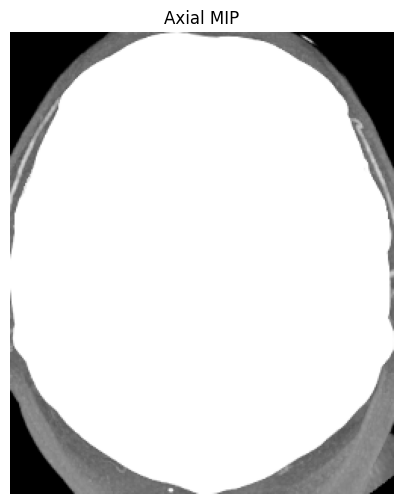

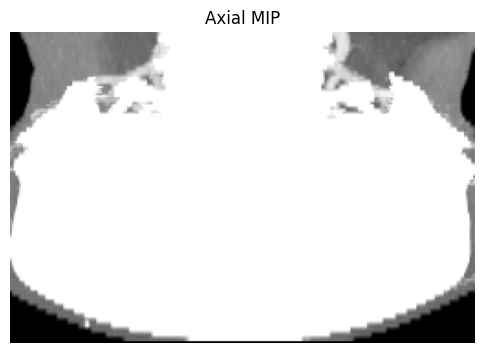

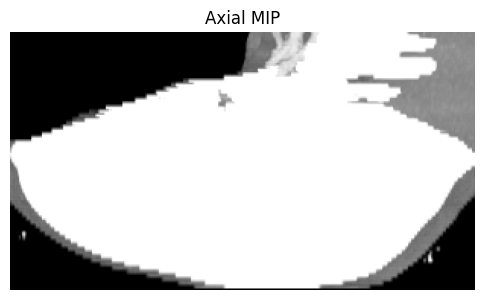

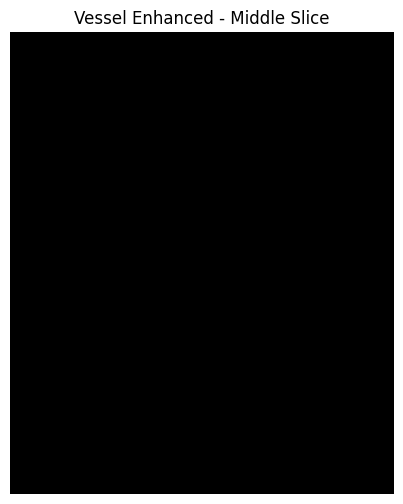

In [527]:
import matplotlib.pyplot as plt

def show_slice(img, title=""):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Show Axial MIP (2D projection)
show_slice(mip_all_ax['axial'], "Axial MIP")
show_slice(mip_all_ax['sagittal'], "Axial MIP")
show_slice(mip_all_ax['coronal'], "Axial MIP")


# Show a middle slice of bone subtracted volume
# mid_slice = bone_removed[bone_removed.shape[0] // 2]
# show_slice(mid_slice, "Bone Subtracted - Middle Slice")

# Show a middle slice of vessel enhancement
mid_slice_ve = vessel_enhanced[vessel_enhanced.shape[0] // 2]
show_slice(mid_slice_ve, "Vessel Enhanced - Middle Slice")


In [209]:
# volume
np.save('cta_test.npy',volume)

In [206]:
from skimage.filters import frangi
import numpy as np

# volume: 3D numpy (Z, Y, X) float, scaled to [0,1]
vesselness = frangi(volume, sigmas=range(1,6,1), black_ridges=False)
# save vesselness as float32 .npy or use as input channel


KeyboardInterrupt: 

# --

In [ ]:
sop = df_ct[df_ct['SOPInstanceUID'] == '1.2.826.0.1.3680043.8.498.10775329348174902199350466348663848346']

In [ ]:
f = r'rsna-intracranial-aneurysm-detection\series'
f_path = os.path.join(f, '1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317')


In [ ]:
import os
# import numpy as np
import pydicom

folder =f_path
for x in os.listdir(folder):
    file = pydicom.dcmread(os.path.join(folder, x))
    if (x == '1.2.826.0.1.3680043.8.498.10775329348174902199350466348663848346.dcm'):
        print(file.InstanceNumber)

163
(276, 512, 512)


In [175]:
local_csv = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train_localizers.csv')

In [ ]:
local_csv[local_csv['SeriesInstanceUID'] == '1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317']

,SeriesInstanceUID,SOPInstanceUID,coordinates,location
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,1.2.826.0.1.3680043.8.498.10775329348174902199...,"{'x': 258.3621186176837, 'y': 261.359900373599}",Other Posterior Circulation


In [ ]:
view_3d_volume(volume)

interactive(children=(IntSlider(value=138, description='slice_index', max=275), Output()), _dom_classes=('widg…

# preprocess pipeline

In [211]:
folder

'rsna-intracranial-aneurysm-detection\\series\\1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317'

In [27]:
import importlib
import preprocess_ct

importlib.reload(preprocess_ct)
from preprocess_ct import preprocess_cta_scan


In [282]:
df_ct[df_ct['SeriesInstanceUID'] =='1.2.826.0.1.3680043.8.498.69955588258737419513349554116268560350']

,Unnamed: 0.1,Unnamed: 0,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,PatientID,PatientAge_x,PatientSex_x,PatientWeight,PatientSize,...,Left Middle Cerebral Artery,Right Middle Cerebral Artery,Anterior Communicating Artery,Left Anterior Cerebral Artery,Right Anterior Cerebral Artery,Left Posterior Communicating Artery,Right Posterior Communicating Artery,Basilar Tip,Other Posterior Circulation,Aneurysm Present
749653,749653,749653,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10002383279970932718...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
749654,749654,749654,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10026178168280820086...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
749655,749655,749655,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10040500344072318612...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
749656,749656,749656,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10054073272307498929...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
749657,749657,749657,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.10063885225094592632...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751089,751089,751089,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.99806660578920601690...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
751090,751090,751090,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.99809767470839306233...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
751091,751091,751091,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.99837424227807183792...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
751092,751092,751092,1.2.826.0.1.3680043.8.498.26875275827756142632...,1.2.826.0.1.3680043.8.498.69955588258737419513...,1.2.826.0.1.3680043.8.498.99932988149488993594...,a187f7ca-a4b,NaN,O,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


In [523]:
vol_old = process_np_scan(os.path.join(f,'1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557'))

(83, 512, 512)


In [524]:
view_3d_volume(vol_old)

interactive(children=(IntSlider(value=41, description='slice_index', max=82), Output()), _dom_classes=('widget…

In [346]:
folder

'rsna-intracranial-aneurysm-detection\\series\\1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317'

In [517]:
df_local = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train_localizers.csv')

In [525]:
df_local[df_local['SeriesInstanceUID'] == '1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557']

,SeriesInstanceUID,SOPInstanceUID,coordinates,location
4,1.2.826.0.1.3680043.8.498.10034081836061566510...,1.2.826.0.1.3680043.8.498.71237104731452368587...,"{'x': 249.86745590416498, 'y': 220.623044646393}",Anterior Communicating Artery


In [514]:
print(df_ct[df_ct['Aneurysm Present']==1].drop_duplicates(subset="SeriesInstanceUID").iloc[3]['SeriesInstanceUID'])
print(df_ct[df_ct['Aneurysm Present']==1].drop_duplicates(subset="SeriesInstanceUID").iloc[3]['SOPInstanceUID'])

df_ct[df_ct['Aneurysm Present']==1].drop_duplicates(subset="SeriesInstanceUID").iloc[3]


1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557
1.2.826.0.1.3680043.8.498.10304208137079626174560405694472881116


Unnamed: 0.1                                                                               3437
Unnamed: 0                                                                                 3437
StudyInstanceUID                              1.2.826.0.1.3680043.8.498.80807788490209335893...
SeriesInstanceUID                             1.2.826.0.1.3680043.8.498.10034081836061566510...
SOPInstanceUID                                1.2.826.0.1.3680043.8.498.10304208137079626174...
PatientID                                                                          4f045e1e-88e
PatientAge_x                                                                               055Y
PatientSex_x                                                                                  M
PatientWeight                                                                               NaN
PatientSize                                                                                 NaN
EthnicGroup                             

In [ ]:
t_f = pydicom.dcmread(r"D:\projects\aneurysm\rsna-intracranial-aneurysm-detection\series\1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557\1.2.826.0.1.3680043.8.498.71237104731452368587327801789352569583.dcm")

In [522]:
t_f.InstanceNumber

'47'

<Axes: ylabel='count'>

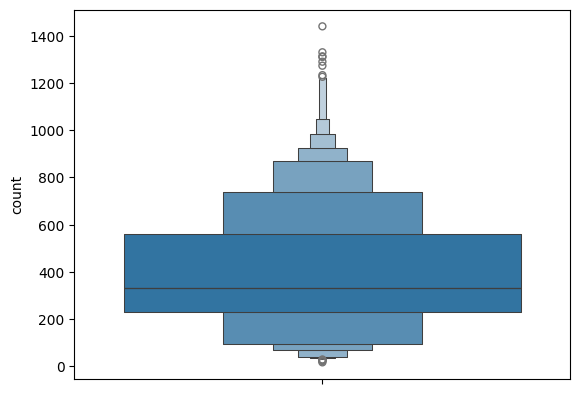

In [540]:
sns.boxenplot(df_ct['SeriesInstanceUID'].value_counts())


In [511]:
vol = preprocess_cta_scan(os.path.join(f,'1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557'))
vol.shape

(170, 306, 254)

In [ ]:
view_3d_volume(vol)

interactive(children=(IntSlider(value=85, description='slice_index', max=169), Output()), _dom_classes=('widge…

# deciding voxel size

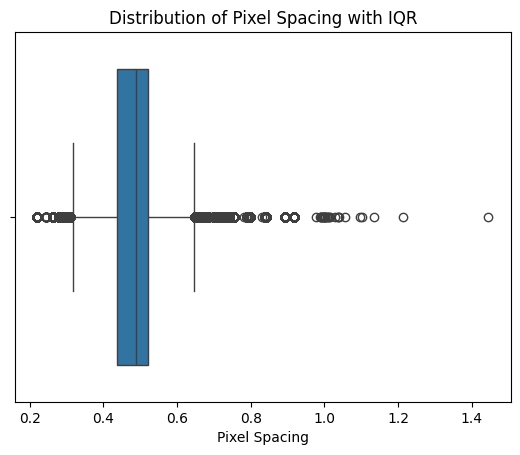

In [448]:
import ast

df_ct["PixelSpacing_val"] = df_ct["PixelSpacing"].apply(lambda x: float(ast.literal_eval(x)[0]))

sns.boxplot(x=df_ct["PixelSpacing_val"])
plt.xlabel("Pixel Spacing")
plt.title("Distribution of Pixel Spacing with IQR")
plt.show()


In [464]:
df_ct["PixelSpacing_val"].quantile(0.9)

np.float64(0.585938)

<Axes: >

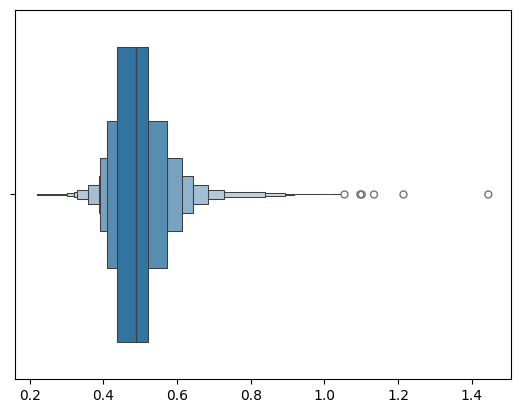

In [451]:
sns.boxenplot(x=values)


<Axes: xlabel='SliceThickness'>

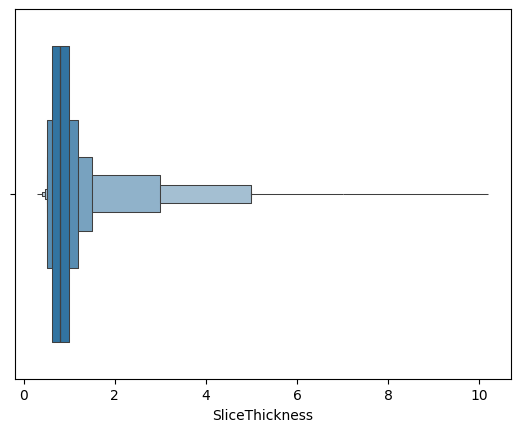

In [454]:
filtered = df_concat['SliceThickness']
filtered = filtered[(filtered <= 100) & (filtered.notna())]

sns.boxenplot(x=filtered)


<Axes: xlabel='SliceThickness'>

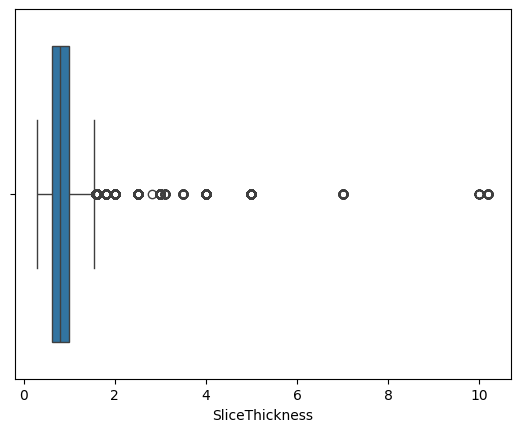

In [458]:
sns.boxplot(x=filtered)

In [462]:
filtered.quantile(0.9)

np.float64(1.2)

# finding neck

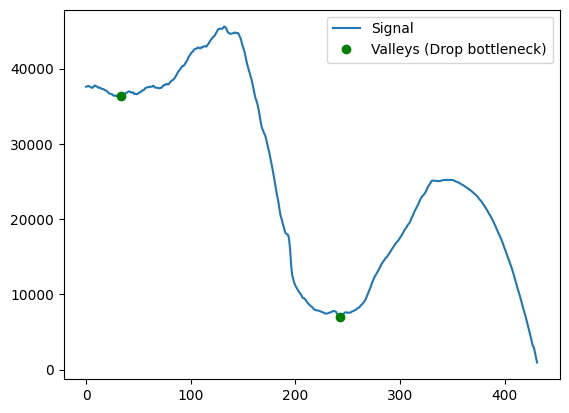

In [ ]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

y=vol
# Find peaks (local maxima)
peaks, _ = find_peaks(y, prominence=1000)  

# Find valleys (local minima) by inverting
valleys, _ = find_peaks(-y, prominence=1000)

# Plot
plt.plot(y, label="Signal")
# plt.plot(peaks, y[peaks], "ro", label="Peaks (Top bottleneck)")
plt.plot(valleys, y[valleys], "go", label="Valleys (Drop bottleneck)")
plt.legend()
plt.show()


In [320]:
np.array(range(0,1,20))

array([0])

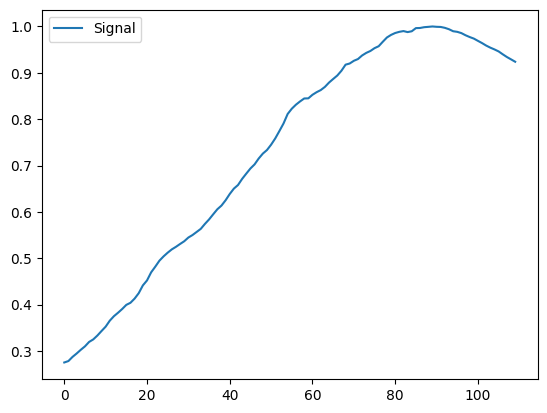

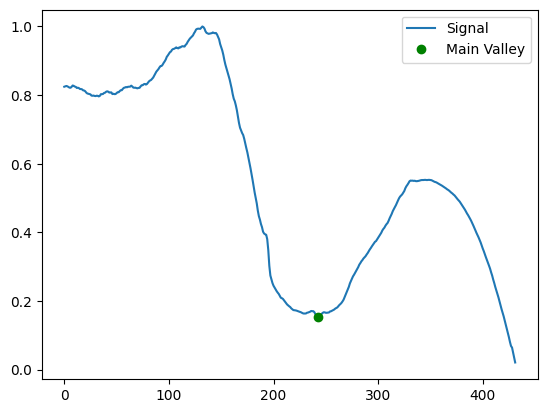

In [ ]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def find_bottlenecks(y):
    # Find peaks and valleys
    peaks, _ = find_peaks(y, prominence=0.005)
    valleys, _ = find_peaks(-y, prominence=0.005)

    peak_idx = None
    valley_idx = None

    if len(peaks) == 0:
        return None, None

    # Case 1: Only one peak
    if len(peaks) > 1:
        valley_idx = valleys[np.argmin(y[valleys])]


    return valley_idx

# Example usage
# x = np.linspace(0, 10, 500)
# y = np.sin(x) + 0.1*x + np.where(x>6, -2, 0)  # custom shape
y=vol/np.max(vol)

peak, valley = find_bottlenecks(y)

plt.plot(y, label="Signal")
if peak is not None:
    plt.plot(peak, y[peak], "ro", label="Main Peak")
if valley is not None:
    plt.plot(valley, y[valley], "go", label="Main Valley")
plt.legend()
plt.show()

y=vol2/np.max(vol2)

peak, valley = find_bottlenecks(y)

plt.plot(y, label="Signal")
if peak is not None:
    plt.plot(peak, y[peak], "ro", label="Main Peak")
if valley is not None:
    plt.plot(valley, y[valley], "go", label="Main Valley")
plt.legend()
plt.show()


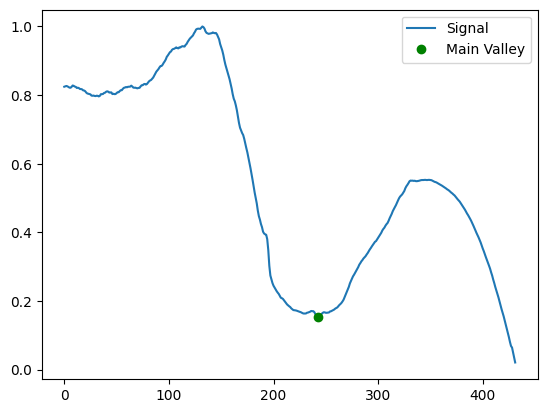

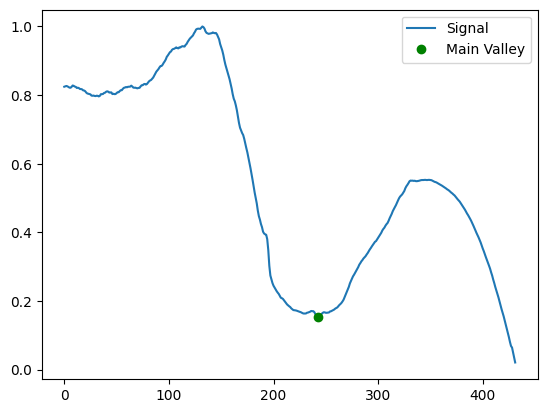

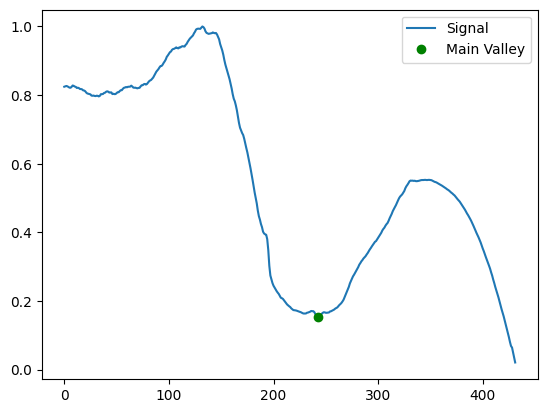

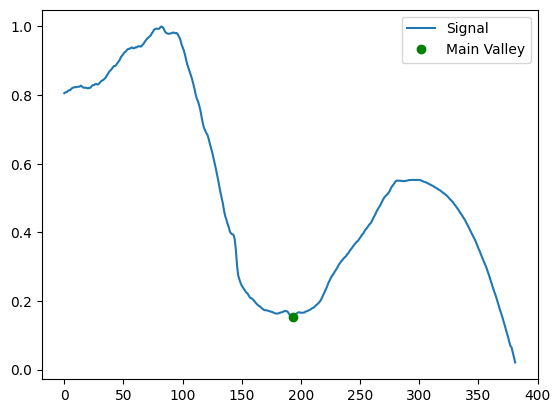

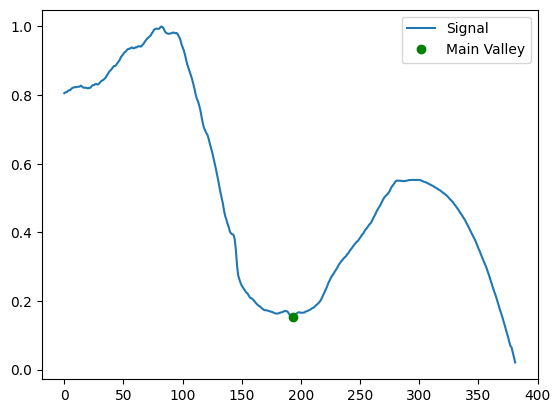

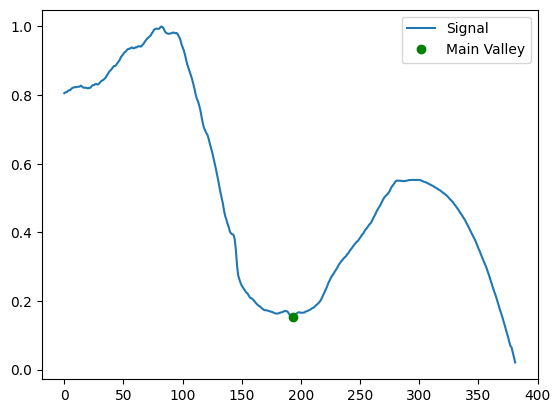

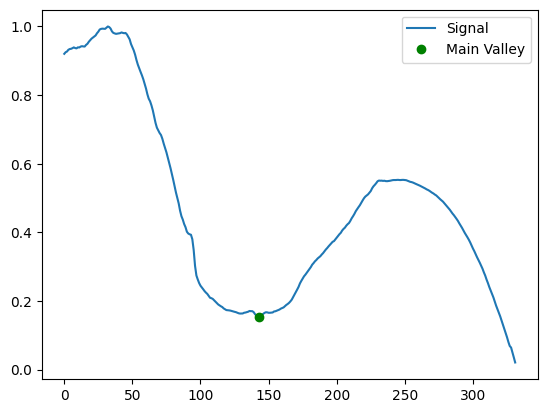

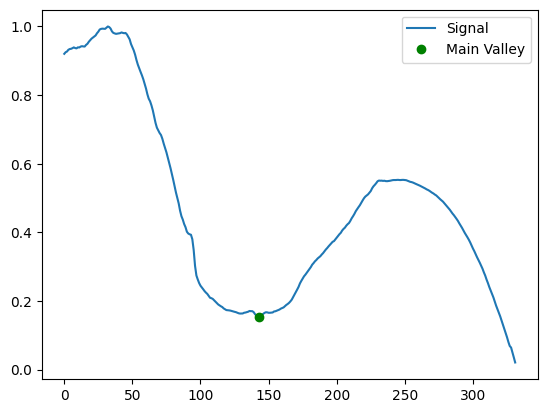

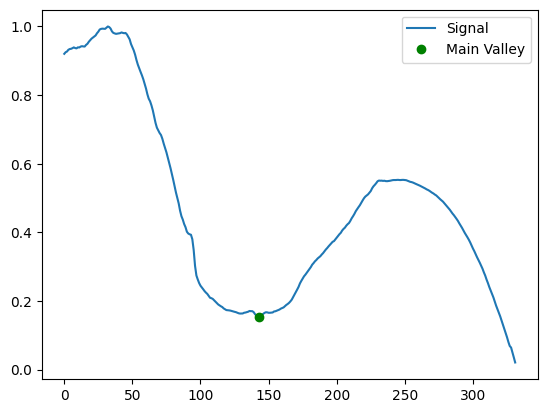

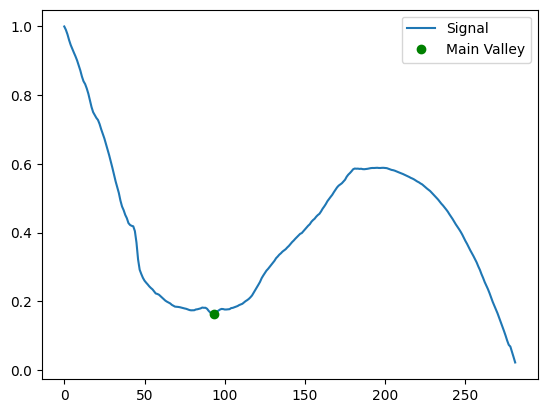

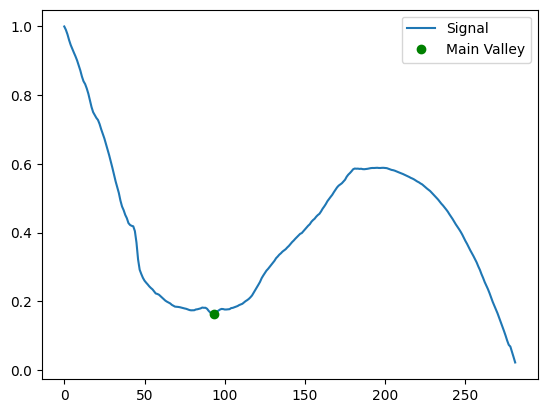

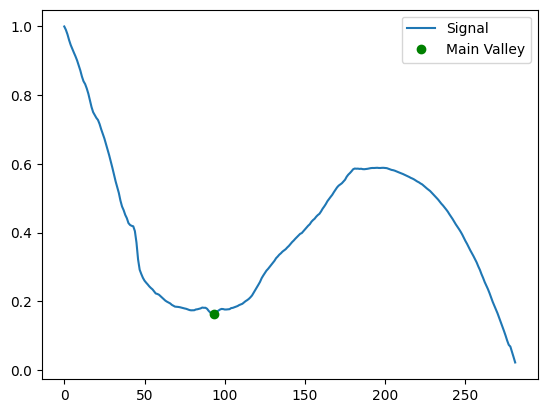

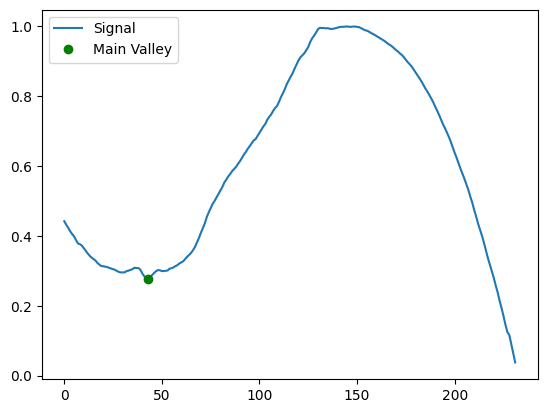

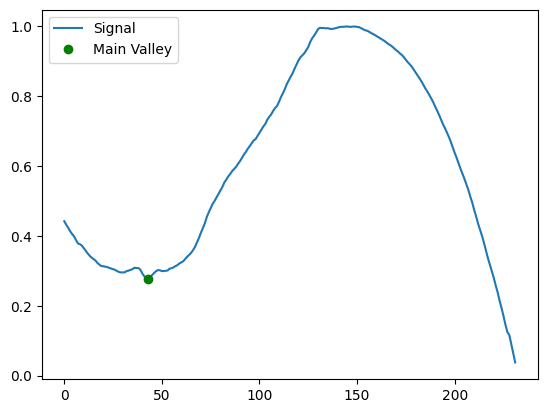

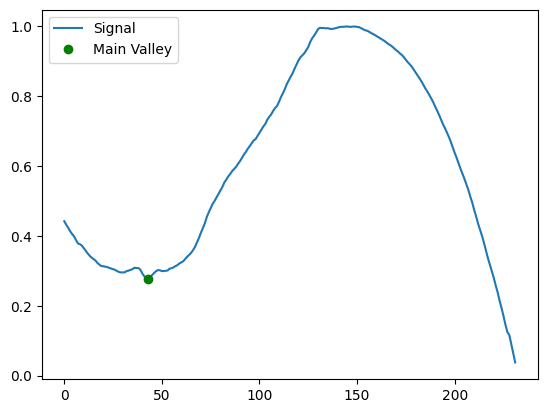

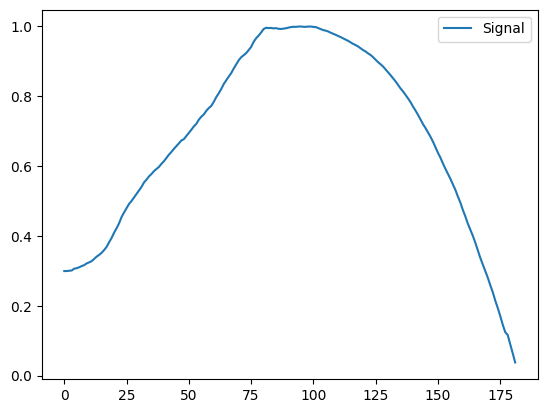

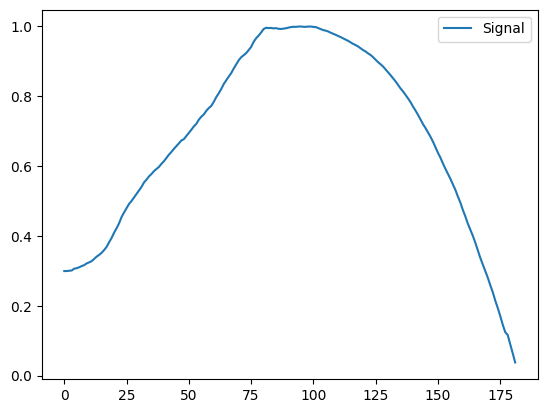

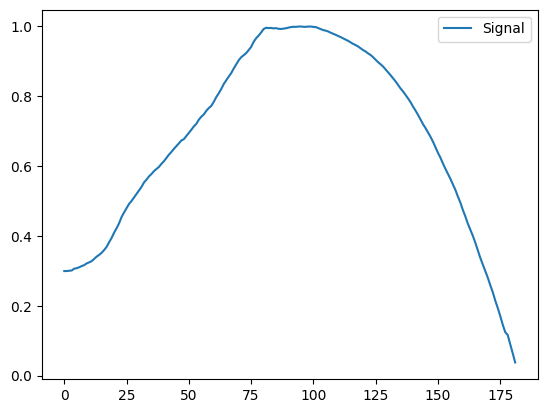

In [376]:
for x in range(0,300,50):
    for y in range(432,310,-50):
        y=vol2[x:]/np.max(vol2[x:])

        peak, valley = find_bottlenecks(y)

        plt.plot(y, label="Signal")
        if peak is not None:
            plt.plot(peak, y[peak], "ro", label="Main Peak")
        if valley is not None:
            plt.plot(valley, y[valley], "go", label="Main Valley")
        plt.legend()
        plt.show()

In [410]:
def find_neck_cutoff(mask: np.ndarray) -> int:
    areas = np.sum(mask, axis=(1, 2))
    areas = (areas - areas.min()) / (areas.max() - areas.min())
    peaks, _ = find_peaks(areas, prominence=0.005)
    valleys, _ = find_peaks(-areas, prominence=0.005)

    valley_idx = None

    if len(peaks) == 0:
        return None, None

    if len(peaks) > 1:
        valley_idx = valleys[np.argmin(areas[valleys])]


    return valley_idx

neck_idx = find_neck_cutoff(vol)


In [407]:
view_3d_volume(vol)

interactive(children=(IntSlider(value=138, description='slice_index', max=275), Output()), _dom_classes=('widg…

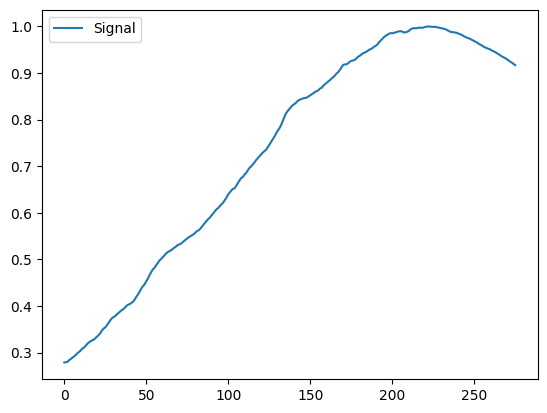

In [ ]:
y=np.sum(vol, axis=(1, 2))/np.max(np.sum(vol, axis=(1, 2)))

# peak, valley = find_bottlenecks(y)

plt.plot(y, label="Signal")
# if peak is not None:
#     plt.plot(peak, y[peak], "ro", label="Main Peak")
if neck_idx is not None:
    plt.plot(neck_idx, y[neck_idx], "go", label="Main Valley")
plt.legend()
plt.show()

# errors in ct preprocess

In [4]:
def percentile_window(hu_image: np.ndarray, p_min: float = 1.0, p_max: float = 99.0) -> np.ndarray:
    """Clips and scales an image based on its own intensity percentiles."""
    # Consider only non-background pixels for percentile calculation
    body_pixels = hu_image[hu_image > -500] 
    if body_pixels.size == 0:
        return np.zeros_like(hu_image, dtype=np.float32)

    hu_min = np.percentile(body_pixels, p_min)
    hu_max = np.percentile(body_pixels, p_max)

    # Avoid division by zero if all values are the same
    if hu_max == hu_min:
        return np.zeros_like(hu_image, dtype=np.float32)

    clipped_image = np.clip(hu_image, hu_min, hu_max)
    scaled_image = (clipped_image - hu_min) / (hu_max - hu_min)
    return scaled_image.astype(np.float32)

# In your pipeline, you would replace apply_hu_window with this
# scaled_image_np = percentile_window(sitk.GetArrayFromImage(reoriented_itk_image))

In [ ]:
import importlib
import preprocess_ct
import view3d_data
importlib.reload(view3d_data)
importlib.reload(preprocess_ct)

<module 'preprocess_ct' from 'd:\\projects\\aneurysm\\preprocess_ct.py'>

In [12]:
from preprocess_ct import *
from view3d_data import view_3d_volume

In [13]:
# Save this as preprocess_ct.py
import SimpleITK as sitk
import numpy as np
import os
from scipy.signal import find_peaks
from typing import Tuple
import seaborn as sns

In [5]:
f = r'rsna-intracranial-aneurysm-detection\series\1.2.826.0.1.3680043.8.498.10021411248005513321236647460239137906'

In [6]:
vol = preprocess_cta_scan(f)

In [29]:
view_3d_volume(vol[0])

interactive(children=(IntSlider(value=62, description='slice_index', max=123), Output()), _dom_classes=('widge…

In [8]:
ort_img, orig_space  = load_and_reorient_dicom(f)
np_ort = sitk.GetArrayFromImage(ort_img)

In [39]:
view_3d_volume(np_ort)

interactive(children=(IntSlider(value=119, description='slice_index', max=238), Output()), _dom_classes=('widg…

In [9]:
hu_img = apply_hu_window(ort_img, (-2000,-100))
view_3d_volume(hu_img)


interactive(children=(IntSlider(value=119, description='slice_index', max=238), Output()), _dom_classes=('widg…

In [63]:
hu_per_img =  percentile_window(np_ort)
view_3d_volume(hu_per_img)

interactive(children=(IntSlider(value=119, description='slice_index', max=238), Output()), _dom_classes=('widg…

In [10]:
head_image_np = crop_neck(np_ort)

view_3d_volume(head_image_np)

interactive(children=(IntSlider(value=105, description='slice_index', max=209), Output()), _dom_classes=('widg…

In [11]:
cropped_head_image_np = crop_to_largest_component(head_image_np)
view_3d_volume(cropped_head_image_np)

interactive(children=(IntSlider(value=105, description='slice_index', max=209), Output()), _dom_classes=('widg…

In [ ]:
percent_head_image_np = percentile_window(cropped_head_image_np)
view_3d_volume(percent_head_image_np)

interactive(children=(IntSlider(value=105, description='slice_index', max=209), Output()), _dom_classes=('widg…

In [ ]:
final_image_np = resample_image(
        cropped_head_image_np,
        current_spacing=orig_space,
        target_spacing=(0.58, 0.58, 1.2)
    )
view_3d_volume(final_image_np)

interactive(children=(IntSlider(value=61, description='slice_index', max=122), Output()), _dom_classes=('widge…

In [27]:
final_image_np[74].shape

(314, 242)

In [16]:
import matplotlib.pyplot as plt

In [ ]:
hu_conv_final_img = robust_hu_conversion(final_image_np, (-2000,-100))

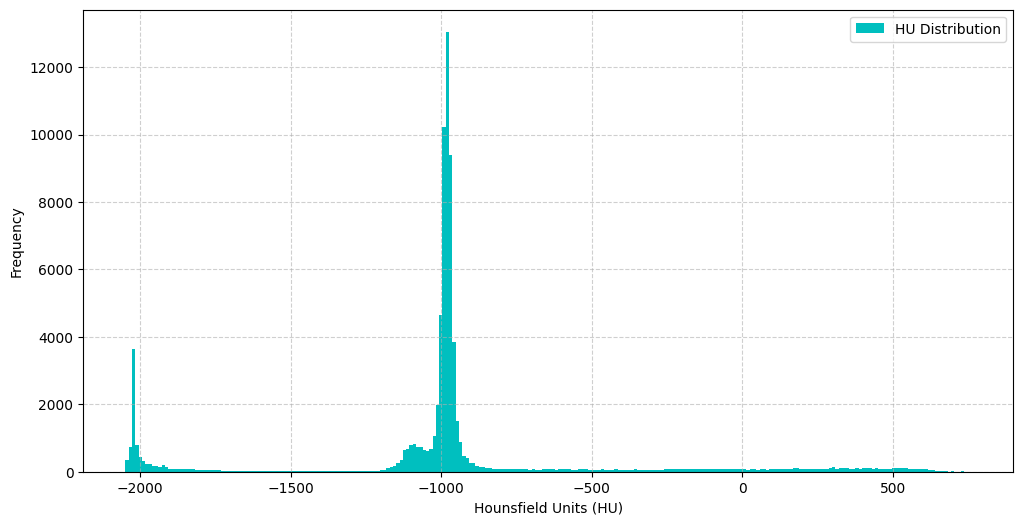

In [28]:
flat_pixels = final_image_np[74].flatten()
if flat_pixels.size > 1_000_000:
    flat_pixels = np.random.choice(flat_pixels, size=1_000_000, replace=False)
plt.figure(figsize=(12, 6))
plt.hist(flat_pixels, bins=256, color='c', label='HU Distribution')
window_vals = None
# If window values are provided, plot them as vertical lines
if window_vals:
    min_val, max_val = window_vals
    plt.axvline(min_val, color='r', linestyle='--', label=f'Window Min: {min_val:.1f}')
    plt.axvline(max_val, color='g', linestyle='--', label=f'Window Max: {max_val:.1f}')
    print(f"Visualizing window: [{min_val:.1f}, {max_val:.1f}]")

plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
mask_test_img = apply_mask(final_image_np, -1300,0, fill_value=-2000)
view_3d_volume(mask_test_img)

interactive(children=(IntSlider(value=61, description='slice_index', max=122), Output()), _dom_classes=('widge…

In [ ]:
percentilt_win_img = percentile_window(mask_test_img)
view_3d_volume(percentilt_win_img)

interactive(children=(IntSlider(value=61, description='slice_index', max=122), Output()), _dom_classes=('widge…

raw

In [ ]:
vol_raw = process_np_scan(f)
view_3d_volume(vol_raw)

(239, 512, 512)


interactive(children=(IntSlider(value=119, description='slice_index', max=238), Output()), _dom_classes=('widg…

finding hu pattern

In [19]:
def displau_hu_distribution(final_image_np):
    flat_pixels = final_image_np.flatten()
    if flat_pixels.size > 1_000_000:
        flat_pixels = np.random.choice(flat_pixels, size=1_000_000, replace=False)
    plt.figure(figsize=(12, 6))
    plt.hist(flat_pixels, bins=256, color='c', label='HU Distribution')
    window_vals = None
    # If window values are provided, plot them as vertical lines
    if window_vals:
        min_val, max_val = window_vals
        plt.axvline(min_val, color='r', linestyle='--', label=f'Window Min: {min_val:.1f}')
        plt.axvline(max_val, color='g', linestyle='--', label=f'Window Max: {max_val:.1f}')
        print(f"Visualizing window: [{min_val:.1f}, {max_val:.1f}]")

    plt.xlabel("Hounsfield Units (HU)")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

In [59]:
f= 'rsna-intracranial-aneurysm-detection\series'

interactive(children=(IntSlider(value=72, description='slice_index', max=144), Output()), _dom_classes=('widge…

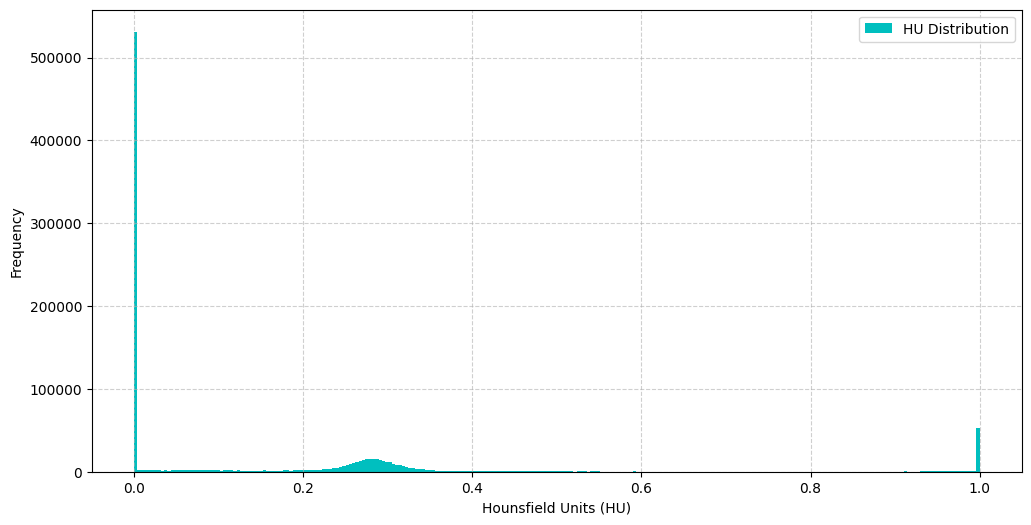

In [158]:
b_img = os.path.join(f,'1.2.826.0.1.3680043.8.498.10484809454170799749997508580496517686')
proc_img_np_b = preprocess_cta_scan(b_img, crop_threshold=0.08)[0]
view_3d_volume(proc_img_np_b)
displau_hu_distribution(proc_img_np_b)

interactive(children=(IntSlider(value=66, description='slice_index', max=132), Output()), _dom_classes=('widge…

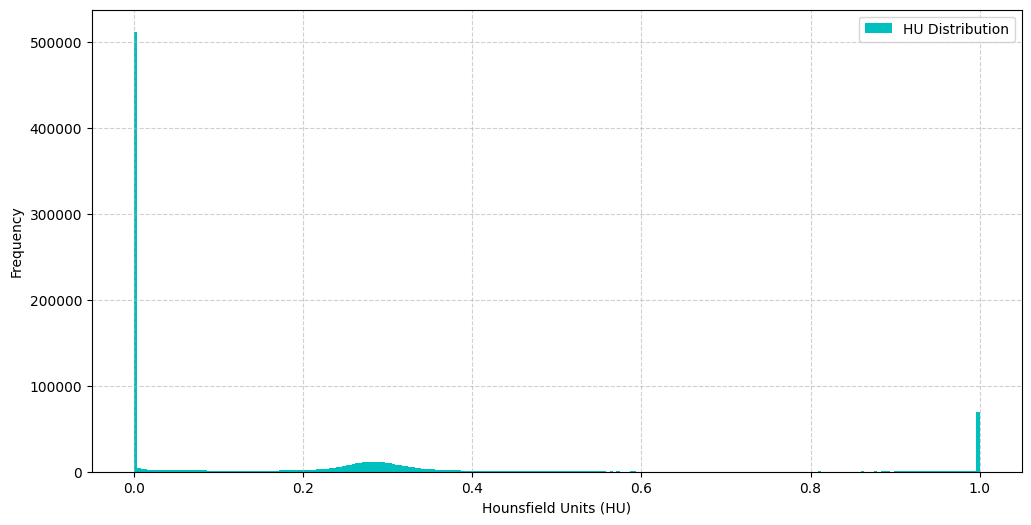

In [159]:
w_img = os.path.join(f,"1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381")
proc_img_np_w = preprocess_cta_scan(w_img, crop_threshold=0.08)[0]
view_3d_volume(proc_img_np_w)
displau_hu_distribution(proc_img_np_w)

In [50]:
import importlib
import preprocess_ct
import view3d_data
importlib.reload(view3d_data)
importlib.reload(preprocess_ct)
from preprocess_ct import *
from view3d_data import *

robust


In [51]:
import os
import matplotlib.pyplot as plt
f= 'rsna-intracranial-aneurysm-detection\series'
def disp_dist_3d(img_name,sof_tissue_range_hu: tuple = (-100,400)):
    img_path = os.path.join(f,img_name)
    proc_img_np = preprocess_cta_scan(img_path,cta_hu_window=sof_tissue_range_hu)[0]
    view_3d_volume(proc_img_np)
    display_hu_distribution(proc_img_np)
def disp_dist_3d_raw(img_name,sof_tissue_range_hu: tuple = (-10000,40000), do_hu=True, disp_hu=True):
    img_path = os.path.join(f,img_name)
    proc_img_np = process_np_scan(img_path, hu=do_hu)
    proc_img_np = apply_window(proc_img_np, sof_tissue_range_hu[0],sof_tissue_range_hu[1])
    if disp_hu:
        display_hu_distribution(proc_img_np[1:-1])
    print(is_zero_a_top_peak(proc_img_np,show_plot=True))
    proc_img_np = (proc_img_np - proc_img_np.min())/(proc_img_np.max() - proc_img_np.min())
    view_3d_volume(proc_img_np)

In [193]:
disp_dist_3d('1.2.826.0.1.3680043.8.498.10030095840917973694487307992374923817') # black error

Processing: 1.2.826.0.1.3680043.8.498.10030095840917973694487307992374923817
  -> REJECTED: Unhandled exception during loading: ufunc 'bitwise_and' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
  -> REJECTED: Failed during initial loading (missing files/data/duplicates).


TypeError: 'NoneType' object is not subscriptable

Aligning head with multi-resolution strategy...
Final transform parameters: (9.775032458080905e-05, 7.918475701022326e-06, -1.4491399645682796e-05, -0.0023308198848103288, 0.008154347452619197, 0.010101662289966317)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 15 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=59, description='slice_index', max=117), FloatSlider(value=0.0, descript…

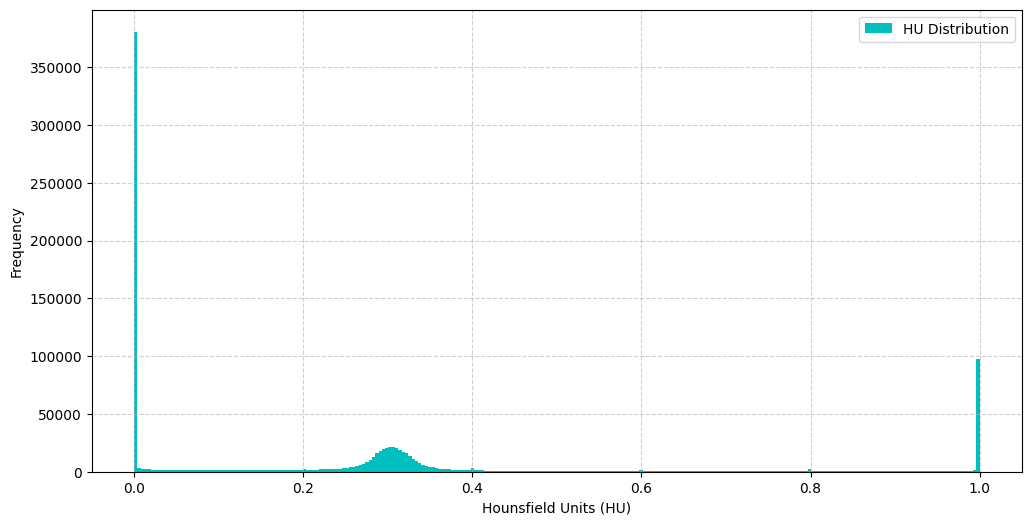

In [ ]:
disp_dist_3d('1.2.826.0.1.3680043.8.498.10177117050965285724806213067235546942') # correcct

Aligning head with multi-resolution strategy...
Final transform parameters: (5.065122818542292e-06, 1.3462018709626641e-05, -0.00016615644191309034, -0.0008792125225476467, -0.0012410605810610964, 0.0013868116701584868)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 16 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=77, description='slice_index', max=153), FloatSlider(value=0.0, descript…

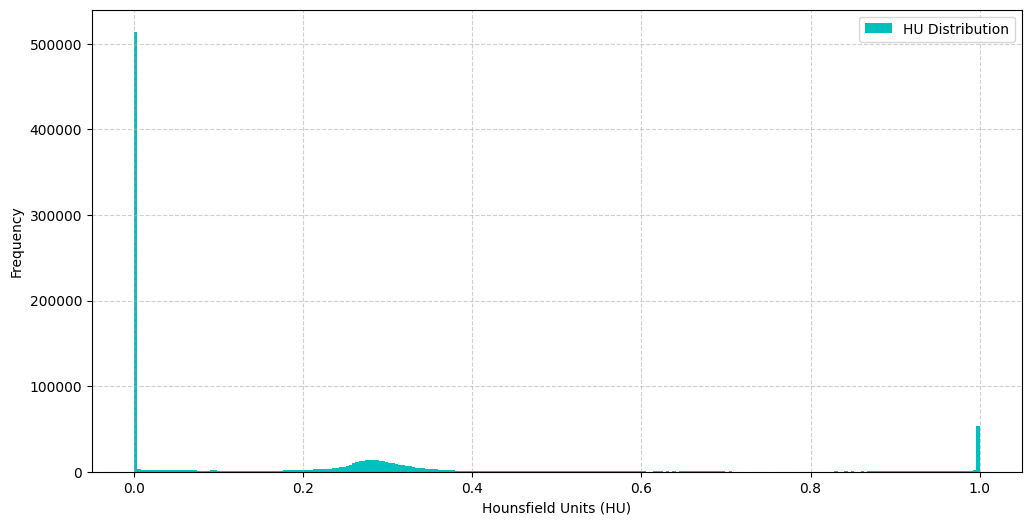

In [ ]:
disp_dist_3d('1.2.826.0.1.3680043.8.498.10315989425857215810912108943640204739') #3

Aligning head with multi-resolution strategy...
Final transform parameters: (-0.00020993993033253993, 4.830720810113096e-05, 7.239303822727064e-06, 0.00010251092186354394, 0.0033642629677266976, 0.0010006693943651961)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 44 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=58, description='slice_index', max=116), FloatSlider(value=0.0, descript…

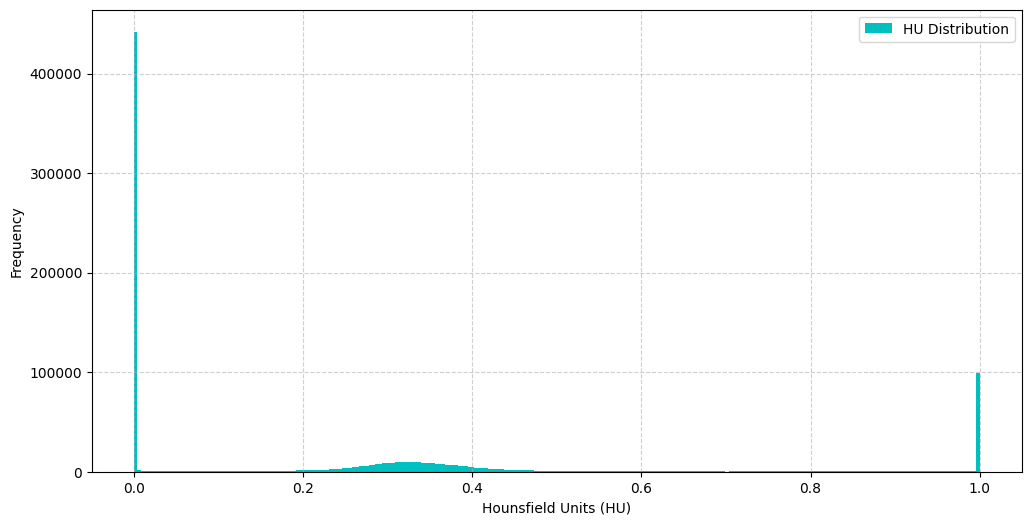

In [ ]:
disp_dist_3d('1.2.826.0.1.3680043.8.498.10355999422630119489122900651916543784') #4

1.2.826.0.1.3680043.8.498.13123105126369783642471112885144484677
Aligning head with multi-resolution strategy...
Final transform parameters: (-1.890603838799859e-05, -3.88210288793588e-06, 3.152726874967842e-06, -0.001221142655493797, -0.0006388414790644712, -0.001593075199767475)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 15 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=79, description='slice_index', max=157), FloatSlider(value=0.0, descript…

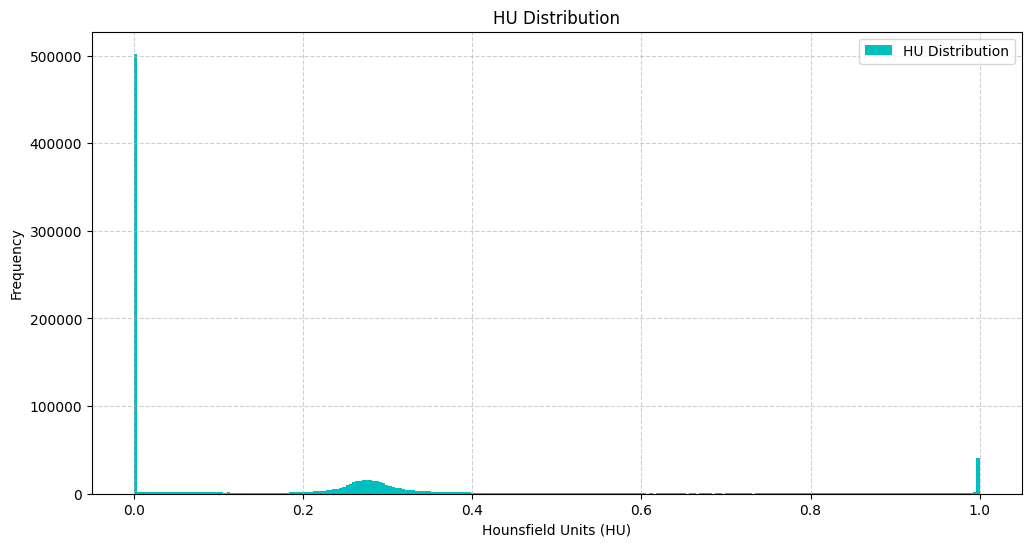

1.2.826.0.1.3680043.8.498.64356599079437255412013580982881766824
Aligning head with multi-resolution strategy...
Final transform parameters: (-0.00028565766500375, -0.00011937980595361778, 0.0002542136330968462, -0.002598565447440866, 0.0031333946256739314, -0.0018153785191329607)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 26 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=66, description='slice_index', max=131), FloatSlider(value=0.0, descript…

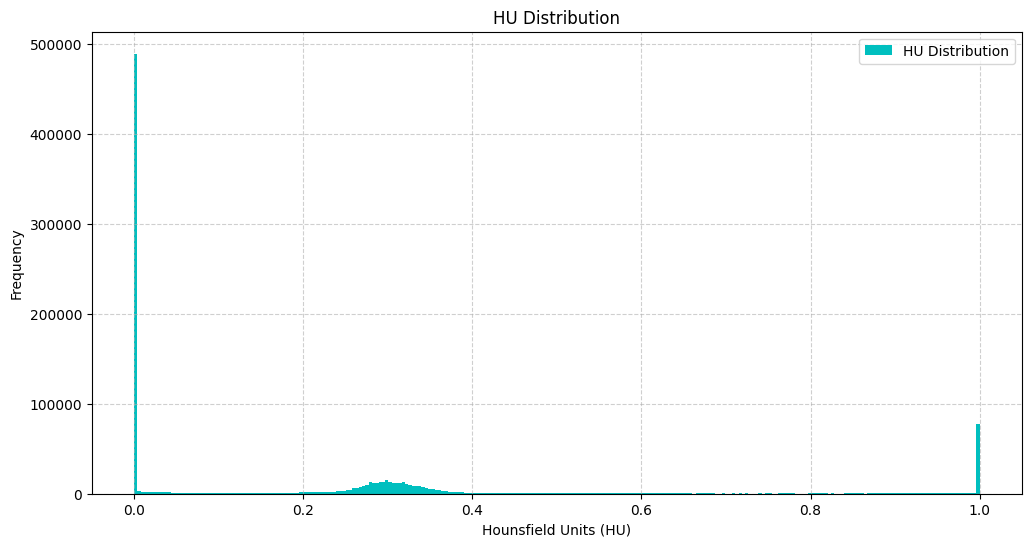

1.2.826.0.1.3680043.8.498.51923383995183466528881495504146352558
Aligning head with multi-resolution strategy...
Final transform parameters: (-2.7479114789415782e-06, 4.262318254215812e-05, -0.00047220819341767267, -0.0038437433273881523, 1.0093148557794518e-05, -0.0005677474672235607)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 25 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=104, description='slice_index', max=207), FloatSlider(value=0.0, descrip…

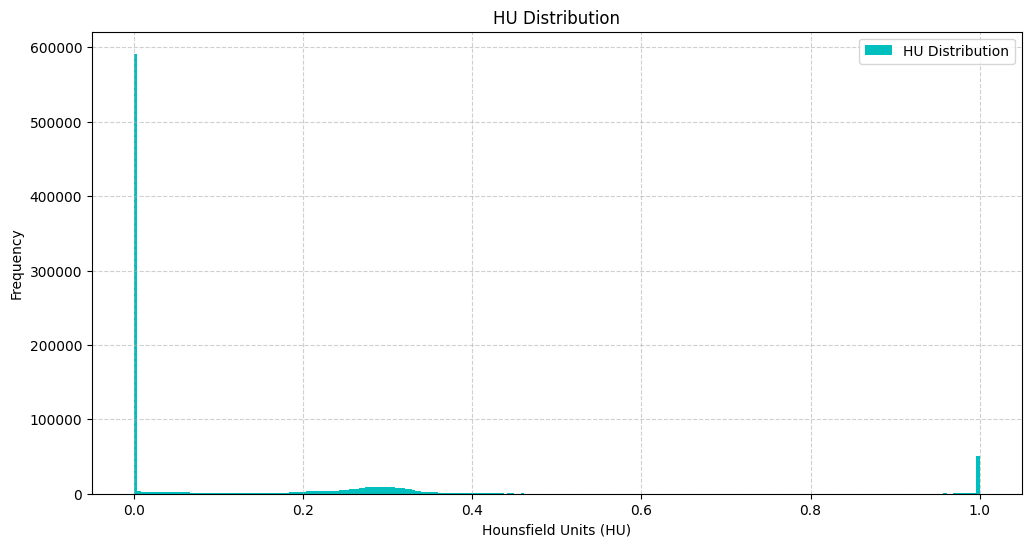

1.2.826.0.1.3680043.8.498.11553710245477993984816277203712389062
Aligning head with multi-resolution strategy...
Final transform parameters: (-6.407147229576659e-06, 3.765507822896783e-06, 3.6059824905998884e-05, 0.0014318093161664511, 0.0003261282749221397, 0.000399329876767298)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 16 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=79, description='slice_index', max=157), FloatSlider(value=0.0, descript…

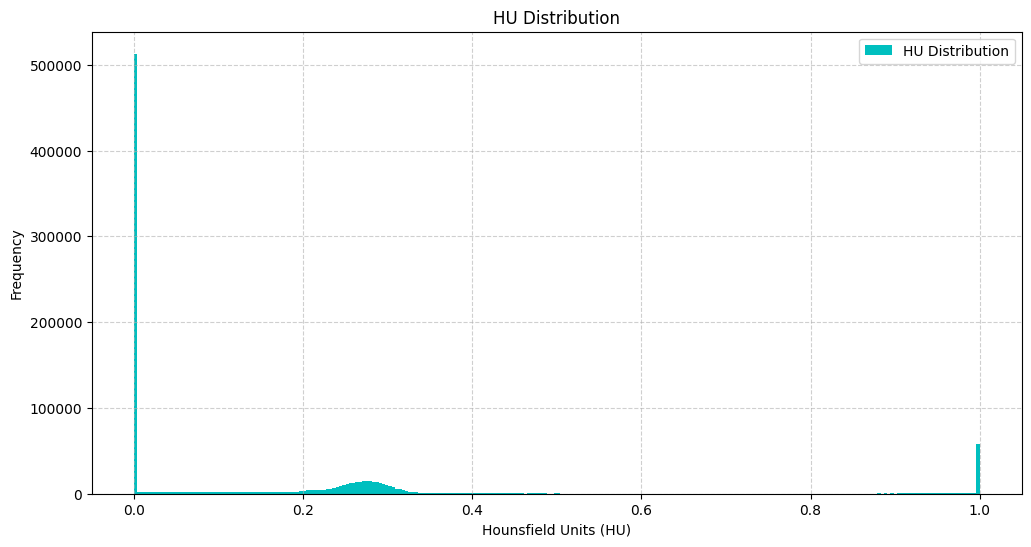

1.2.826.0.1.3680043.8.498.21004106426734635526381567602936015568
Aligning head with multi-resolution strategy...
Final transform parameters: (-2.4152566219980355e-05, 4.119726026634971e-05, -7.313376858460389e-05, -0.0009251913587908316, -0.000998690436382268, 0.00047122281295889853)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 14 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=78, description='slice_index', max=155), FloatSlider(value=0.0, descript…

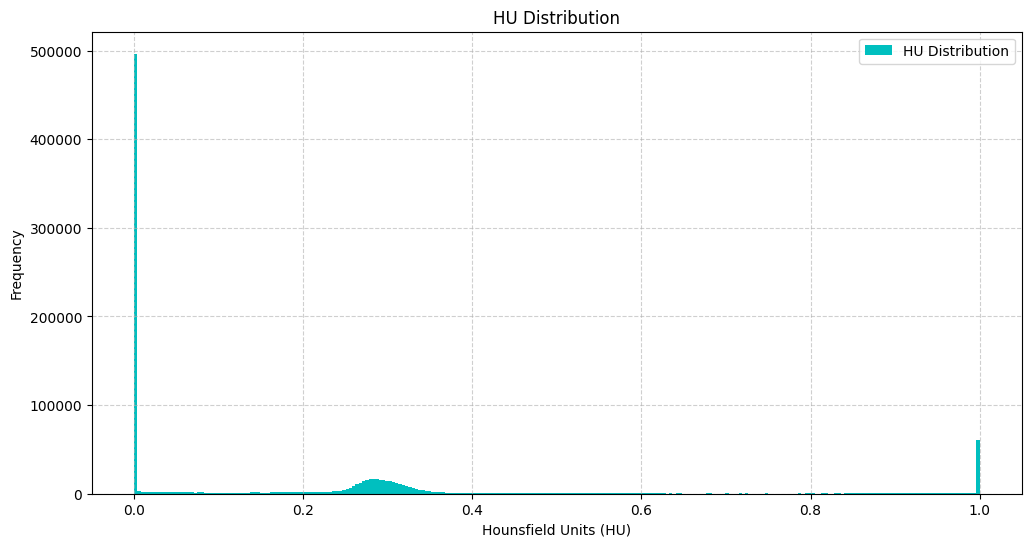

In [56]:
import random
train_csv = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')
for x in range(5):
    rand_int = random.randint(0,1856)
    print(train_csv[train_csv['Modality']=='CTA']['SeriesInstanceUID'].iloc[rand_int])
    disp_dist_3d(train_csv[train_csv['Modality']=='CTA']['SeriesInstanceUID'].iloc[rand_int],sof_tissue_range_hu=(-100,400))

In [57]:
import numpy as np
import sounddevice as sd
import random

def play_random_sound(duration=6.0, samplerate=44100):
    """
    Generate a random sine wave tone and play it.
    
    Args:
        duration (float): Duration of the sound in seconds.
        samplerate (int): Sampling rate (Hz).
    """
    # Pick a random frequency between 200 Hz and 1000 Hz
    freq = random.uniform(200, 1000)
    
    # Generate time points
    t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)
    
    # Generate sine wave
    waveform = np.sin(2 * np.pi * freq * t)
    
    # Play the sound
    sd.play(waveform, samplerate)
    sd.wait()  # Wait until playback is finished
    
    print(f"Played sound at {freq:.2f} Hz for {duration} sec.")

# Example usage:
play_random_sound()


Played sound at 638.82 Hz for 6.0 sec.


In [ ]:
# 1.2.826.0.1.3680043.8.498.70128862898305387932830693881247457838 neck issue didnt crop the  lungs
# 1.2.826.0.1.3680043.8.498.13335964305225206928775602392466294131 neck issue didnt crop the  lungs
# 1.2.826.0.1.3680043.8.498.33846340251863147853963750710189797262 neck issue didnt crop the  lungs
# 1.2.826.0.1.3680043.8.498.55842513583959788633621451208426913881 neck issue didnt crop the  lungs
# 1.2.826.0.1.3680043.8.498.39467198872118696167396371980096058294 Zero-valued spacing duplicate file earlier now weird distorted hard to make out any thing
# 1.2.826.0.1.3680043.8.498.63659290871058751026573871222273656938 weird output, the orignal raw image contains weird scale and so does the preprocessed one , aslo the raw contains very grey kind of image nothing is clear and so does th preprocessed, but if seen in online dicom viewer everything looks fine except few last layer contianing the scale
# 1.2.826.0.1.3680043.8.498.13335964305225206928775602392466294131 ghostly rotation
# 1.2.826.0.1.3680043.8.498.58589055647662366504429258517414401474 ghostly artifactes
# 1.2.826.0.1.3680043.8.498.92992276747850659581372427486356669050 ghostly artifactes with wirrd shape
# 1.2.826.0.1.3680043.8.498.55312140736376805090207300509119568749 head tilted with ghostly artifact
# 1.2.826.0.1.3680043.8.498.92056690496906870388278135359377950919 blurry veins
# 1.2.826.0.1.3680043.8.498.60670218048819498377792714090864644130 head still tilted
# 1.2.826.0.1.3680043.8.498.13360367168266629638875527696789835233 head tilted
# 1.2.826.0.1.3680043.8.498.55739661839410824277181104551132162001 head tlted
# 1.2.826.0.1.3680043.8.498.25275992011180141891131545878400938893 brain veins masked
# 1.2.826.0.1.3680043.8.498.10311178483256099259176768310869377326 all white brain wtih other artifacts orignal raw image is also white with the same weird scale like, artifact at frame 0. if loaded in online dicom viewer everything is clearly visible with that weird scale at 0
# 1.2.826.0.1.3680043.8.498.92273881219564445904813475221795009966 weird view totally messed up saggital view image
# 1.2.826.0.1.3680043.8.498.46816863046401626630171510930377063530 weird view messed up saggital view image
# 1.2.826.0.1.3680043.8.498.44307226922118927848453494136198068182 cropped head front
# some scans if seen though online viewer perfeclty show veins at correct brain hu window , while some show black in brain window and perfectly in lungs window

(121, 512, 512)


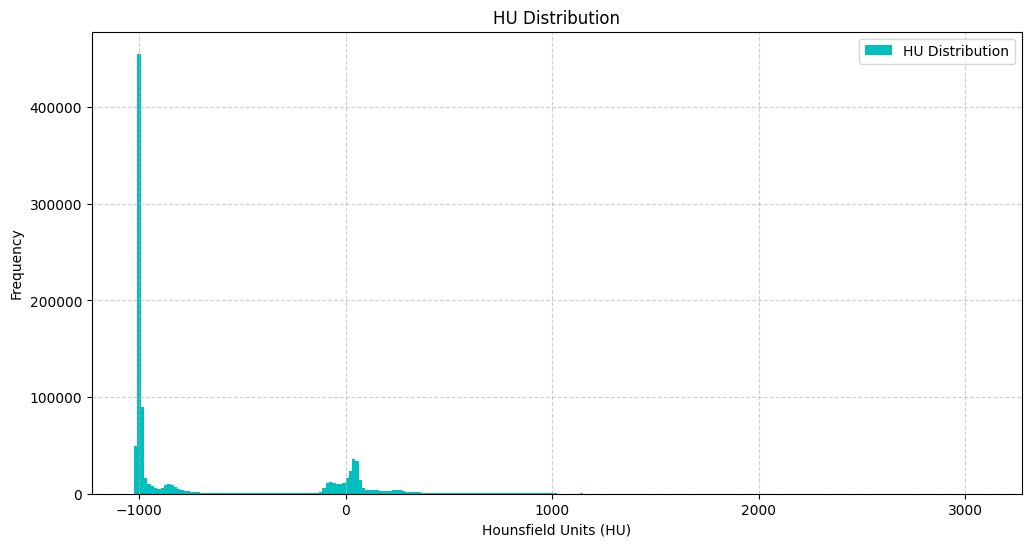

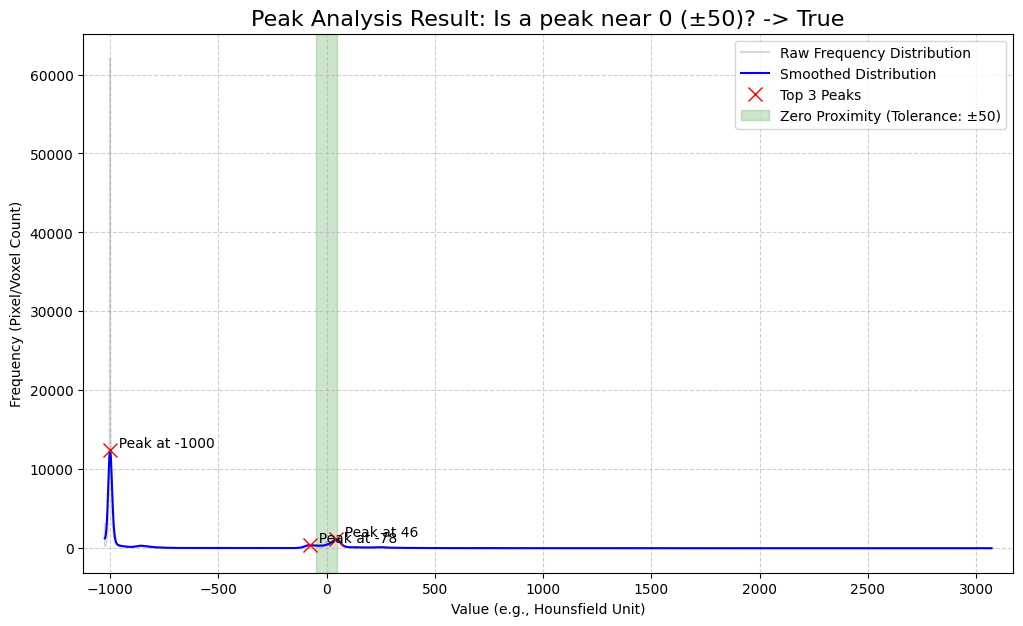

True


interactive(children=(IntSlider(value=60, description='slice_index', max=120), FloatSlider(value=0.0, descript…

In [ ]:
disp_dist_3d_raw('1.2.826.0.1.3680043.8.498.28834759031749908084205048939517178175')

(75, 512, 512)


interactive(children=(IntSlider(value=37, description='slice_index', max=74), FloatSlider(value=0.0, descripti…

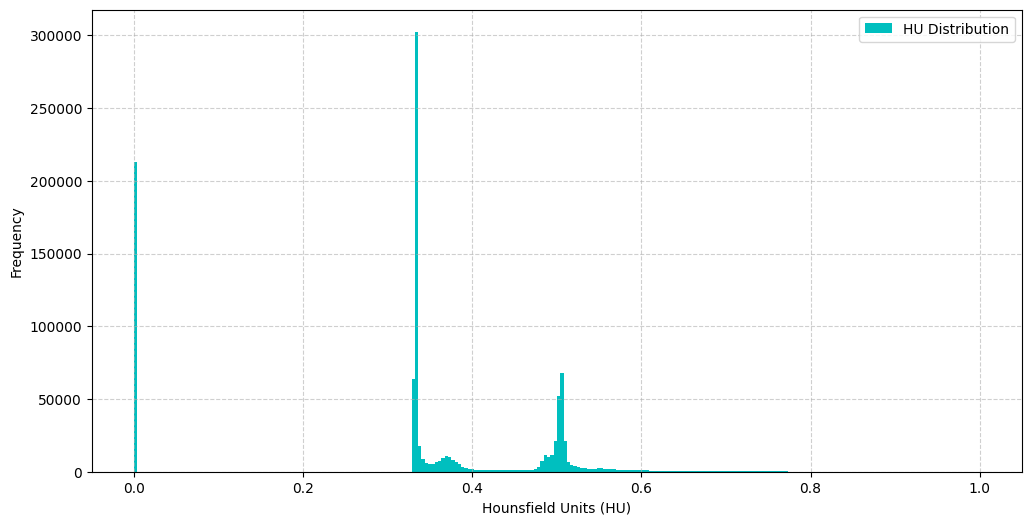

In [ ]:
disp_dist_3d_raw('1.2.826.0.1.3680043.8.498.50268462808449401128173812870329002342')

In [124]:
df_ct[df_ct['SeriesInstanceUID'] == '1.2.826.0.1.3680043.8.498.10998551301428376772035074358827982227']['Aneurysm Present'].iloc[0]

np.int64(0)

In [ ]:
import os
import pydicom

# Base directory
base_path = r'D:\projects\aneurysm\rsna-intracranial-aneurysm-detection\series'

# Subfolder UID
series_uid = r'1.2.826.0.1.3680043.8.498.13038612585916787394270769114805405156'
# rand_int = random.randint(0,1856)
# series_uid  = train_csv[train_csv['Modality']=='CTA']['SeriesInstanceUID'].iloc[rand_int]
# Full series path
series_path = os.path.join(base_path, series_uid)

# Pick the 27th file (index 26)
dcm_file = os.listdir(series_path)[26]

# Build full file path
dcm_path = os.path.join(series_path, dcm_file)

# Read dicom file
dic = pydicom.dcmread(dcm_path)

print(dic.PhotometricInterpretation)

for elem in dic.iterall():
    print(f"{elem.tag} | {elem.keyword:35} | {repr(elem.value)[:80]}")


MONOCHROME2
(0008,0005) | SpecificCharacterSet                | 'ISO_IR 100'
(0008,0008) | ImageType                           | ['DERIVED', 'PRIMARY', 'AXIAL', 'CT_SOM5 MPR', 'STD', 'DNRG', 'DET_AB']
(0008,0016) | SOPClassUID                         | '1.2.840.10008.5.1.4.1.1.2'
(0008,0018) | SOPInstanceUID                      | '1.2.826.0.1.3680043.8.498.12975888320238920088857236096809892001'
(0008,0020) | StudyDate                           | '20170924'
(0008,0021) | SeriesDate                          | '20170924'
(0008,0022) | AcquisitionDate                     | '20170924'
(0008,0023) | ContentDate                         | '20170924'
(0008,002A) | AcquisitionDateTime                 | '20170924011924.605000'
(0008,0030) | StudyTime                           | '010500'
(0008,0031) | SeriesTime                          | '012256.912000'
(0008,0032) | AcquisitionTime                     | '011924.605000'
(0008,0033) | ContentTime                         | '011924.605000'
(0008,0

In [2]:
import pandas as pd

In [3]:
metadata_df = pd.read_csv('metadata_df.csv')

C:\Users\solan\AppData\Local\Temp\ipykernel_20024\88472766.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv('metadata_df.csv')


In [5]:
train_csv = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')

In [6]:
train_csv['Modality'].value_counts()

Modality
CTA           1857
MRA           1256
MRI T2         986
MRI T1post     306
Name: count, dtype: int64

Aligning head with multi-resolution strategy...
Final transform parameters: (2.0352106598868354e-05, -8.577247812691895e-06, 9.538792372480301e-06, 0.00011823700440044649, -0.0038126539054534414, -0.003211849585216305)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 11 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=51, description='slice_index', max=101), FloatSlider(value=0.0, descript…

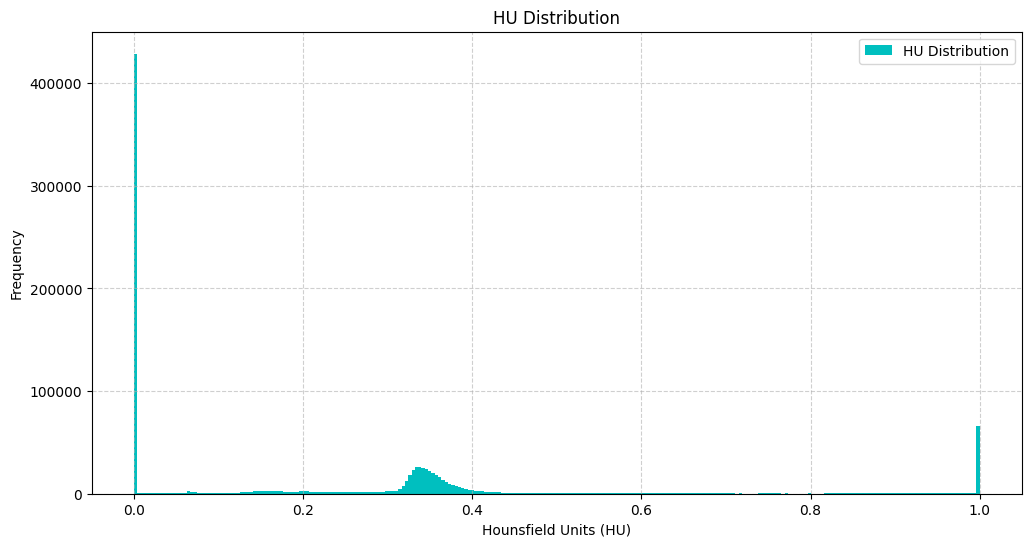

In [52]:
disp_dist_3d(r'1.2.826.0.1.3680043.8.498.10052893794239333131781802642788307307',sof_tissue_range_hu=(-200,500))

Aligning head with multi-resolution strategy...
Final transform parameters: (5.385646898792657e-06, 1.5108622202476748e-05, 1.127800593880521e-05, 0.001295936377825284, 0.0005025697457821392, -0.0012866466992706754)
Optimizer stop condition: RegularStepGradientDescentOptimizerv4: Step too small after 13 iterations. Current step (0.000976562) is less than minimum step (0.001).


interactive(children=(IntSlider(value=73, description='slice_index', max=146), FloatSlider(value=0.0, descript…

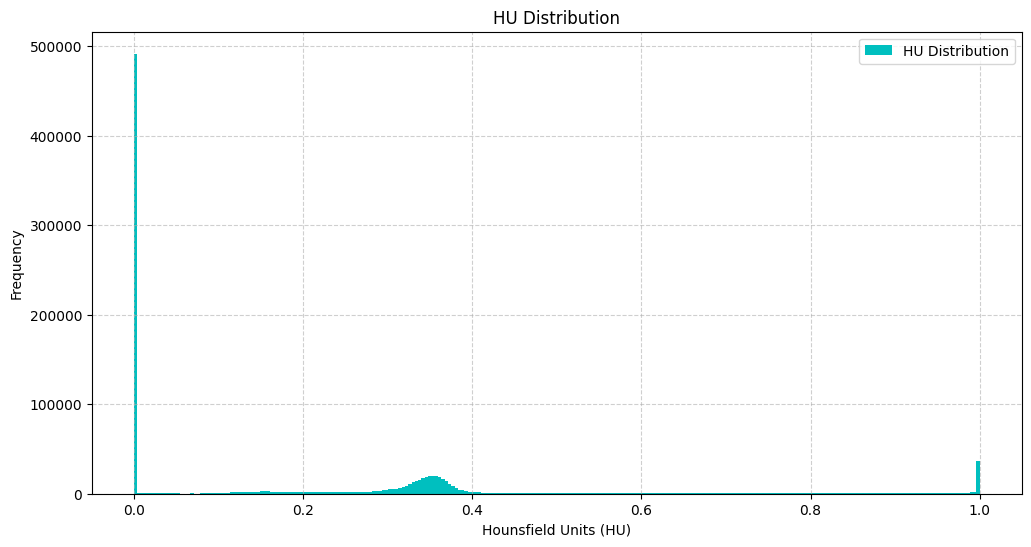

In [ ]:
disp_dist_3d(r'1.2.826.0.1.3680043.8.498.10195070873338721244150818495996796822',sof_tissue_range_hu=(-200,500))

(289, 512, 512)


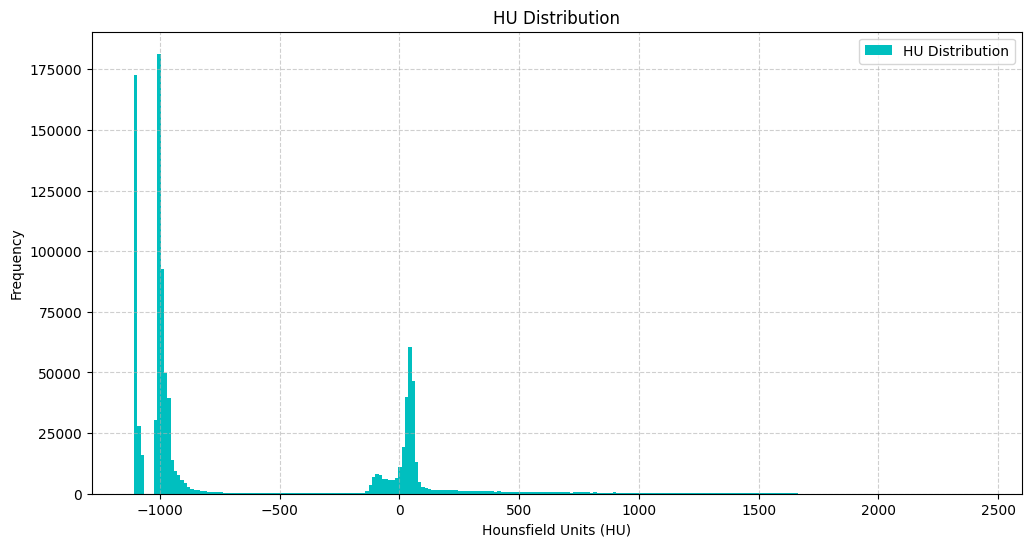

interactive(children=(IntSlider(value=144, description='slice_index', max=288), FloatSlider(value=0.0, descrip…

In [11]:
disp_dist_3d_raw(r'1.2.826.0.1.3680043.8.498.10195070873338721244150818495996796822',sof_tissue_range_hu=(-20000,50000)) # no hu

(169, 512, 512)


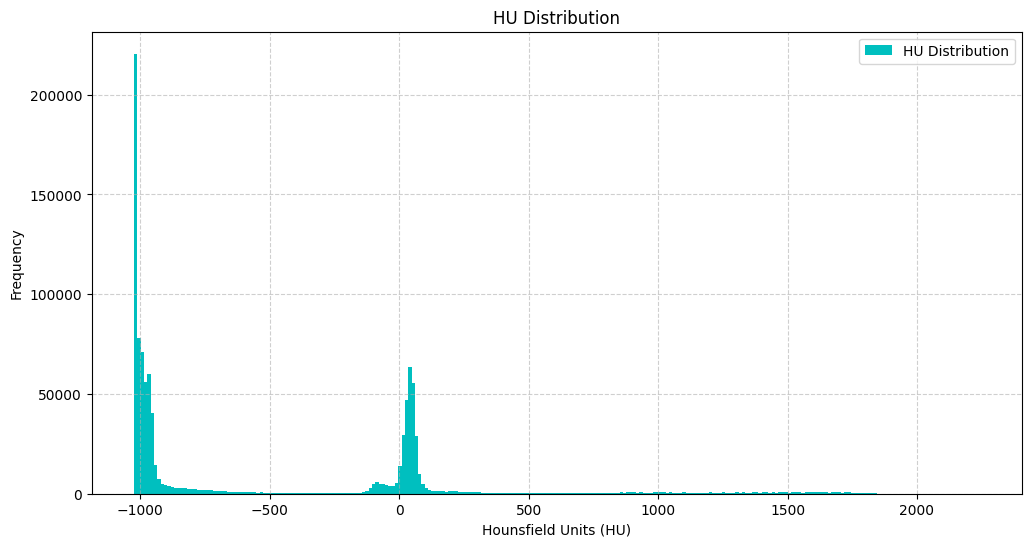

interactive(children=(IntSlider(value=84, description='slice_index', max=168), FloatSlider(value=0.0, descript…

In [ ]:
disp_dist_3d_raw(r'1.2.826.0.1.3680043.8.498.10118061831005170945889563029918713432',sof_tissue_range_hu=(-20000,50000))# no hu

converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to hu
converting to 

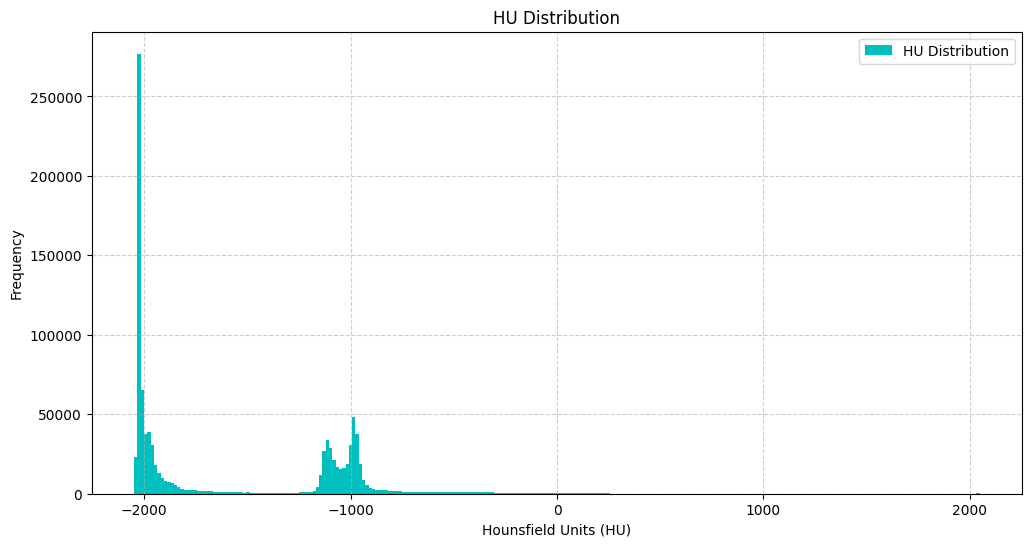

interactive(children=(IntSlider(value=78, description='slice_index', max=155), FloatSlider(value=0.0, descript…

In [31]:
disp_dist_3d_raw(r'1.2.826.0.1.3680043.8.498.10242740813399049394757933972926370746',sof_tissue_range_hu=(-20000,50000))#no hu req but

(33, 584, 512)


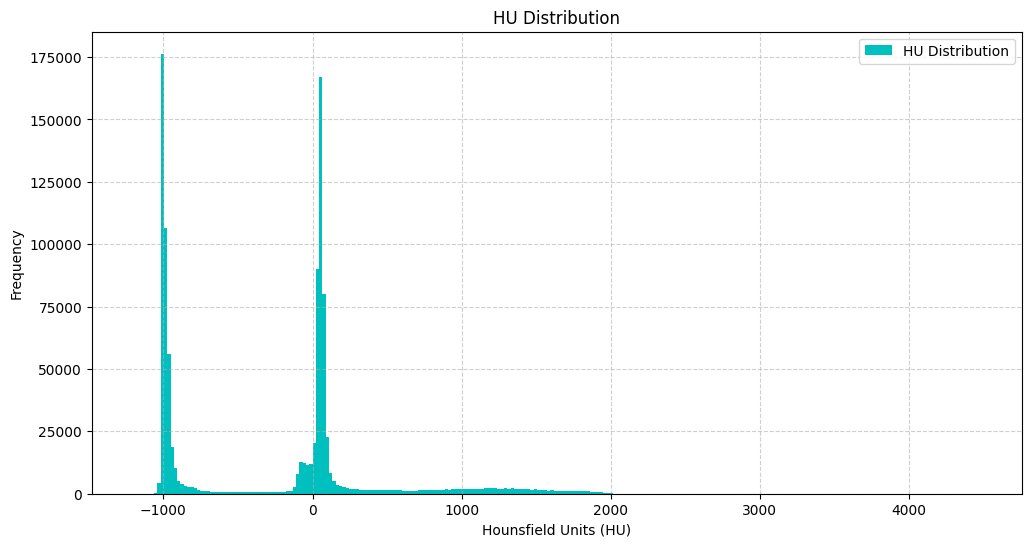

interactive(children=(IntSlider(value=16, description='slice_index', max=32), FloatSlider(value=0.0, descripti…

In [ ]:
disp_dist_3d_raw(r'1.2.826.0.1.3680043.8.498.10163827504601437014258638041508575801',do_hu=False)#no hu req but

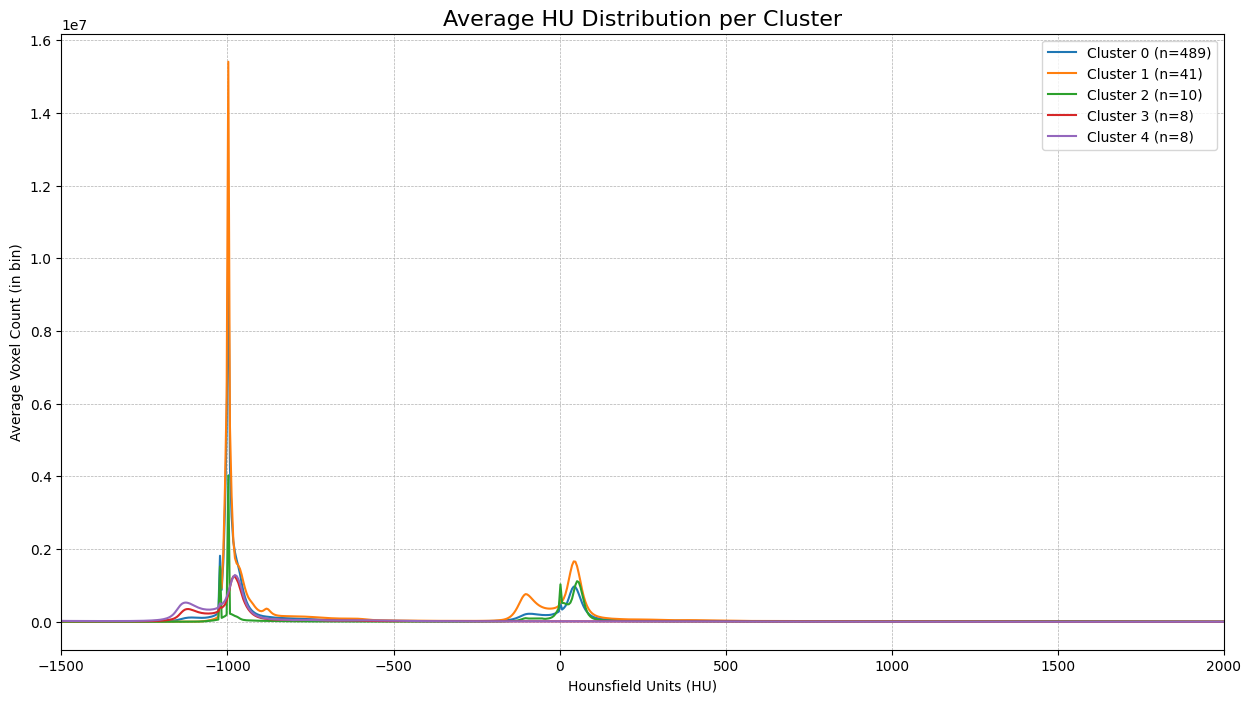

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Directory where your CSVs are saved
output_dir = 'scan_clusters_dbscan' 
num_clusters = 5

# Define the histogram range and bins you used in the script
HIST_RANGE = (-2000, 3000)
HIST_BINS = 1000
bin_edges = np.linspace(HIST_RANGE[0], HIST_RANGE[1], HIST_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(15, 8))
plt.title('Average HU Distribution per Cluster', fontsize=16)

for i in range(num_clusters):
    filepath = f'{output_dir}/cluster_{i}_data.csv'
    try:
        df_cluster = pd.read_csv(filepath)
        
        # Drop the ID column to calculate the mean
        features = df_cluster.drop('scan_id', axis=1)
        
        # Calculate the average histogram for this cluster
        average_histogram = features.mean(axis=0)
        
        # Plot it
        plt.plot(bin_centers, average_histogram, label=f'Cluster {i} (n={len(df_cluster)})')
        
    except FileNotFoundError:
        print(f"File not found for cluster {i}. Skipping.")

plt.xlabel('Hounsfield Units (HU)')
plt.ylabel('Average Voxel Count (in bin)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlim(-1500, 2000) # Zoom in on the most relevant HU range
plt.show()

In [13]:
output_dir =  'scan_clusters_dbscan_t2'
c1_df = pd.read_csv(f'{output_dir}/cluster_0_data.csv')
c2_df = pd.read_csv(f'{output_dir}/cluster_1_data.csv')
c3_df = pd.read_csv(f'{output_dir}/cluster_2_data.csv')
ou_df = pd.read_csv(f'{output_dir}/outliers_data.csv')

In [9]:
import seaborn as sns

In [11]:
import random
import  pandas as pd

(908, 512, 512)


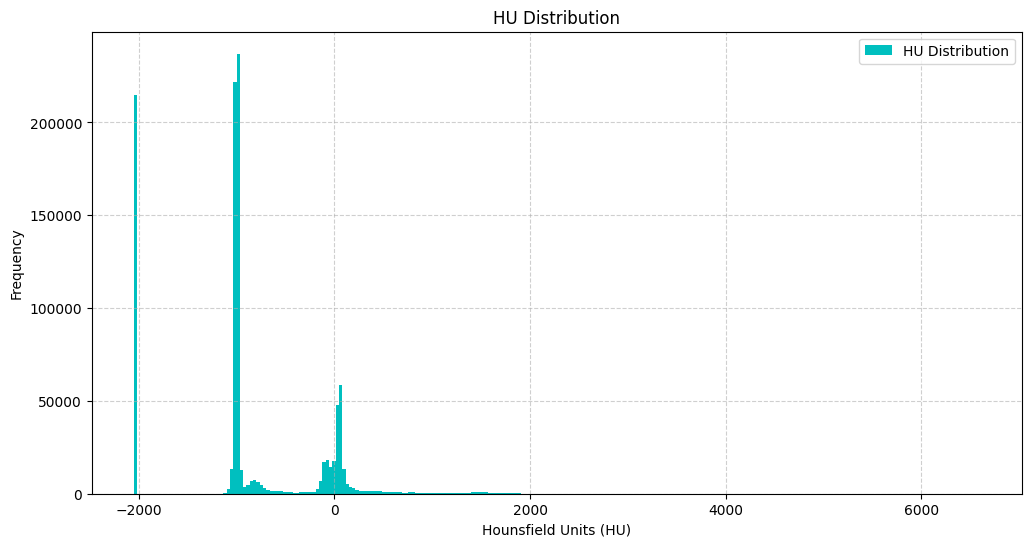

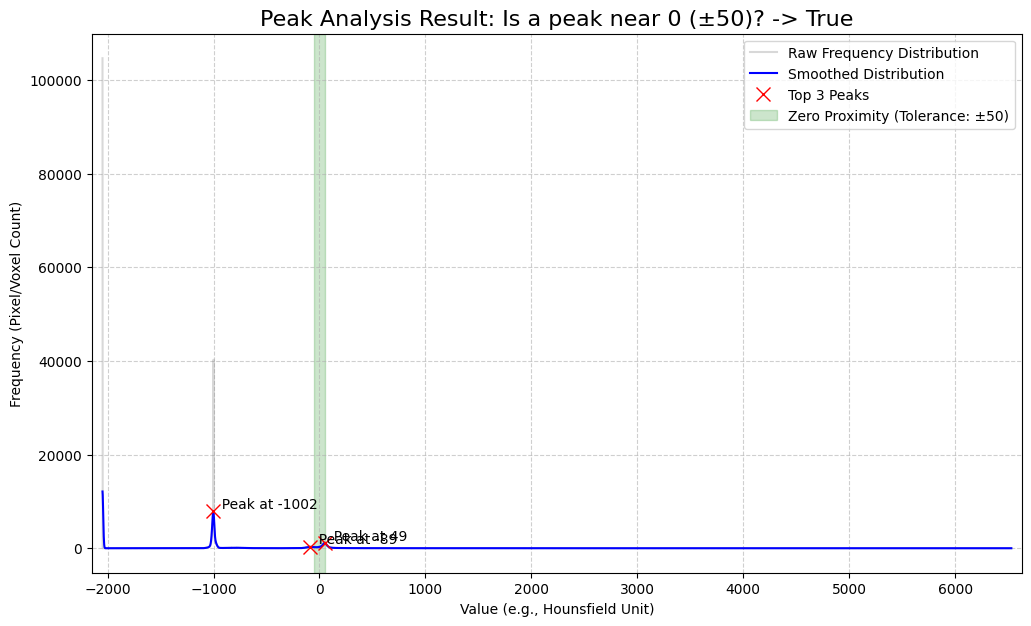

True


interactive(children=(IntSlider(value=454, description='slice_index', max=907), FloatSlider(value=0.0, descrip…

In [43]:
disp_dist_3d_raw(c1_df.iloc[random.randint(0,len(c1_df))]['scan_id'],do_hu=False) # 0 -1000

(349, 512, 512)


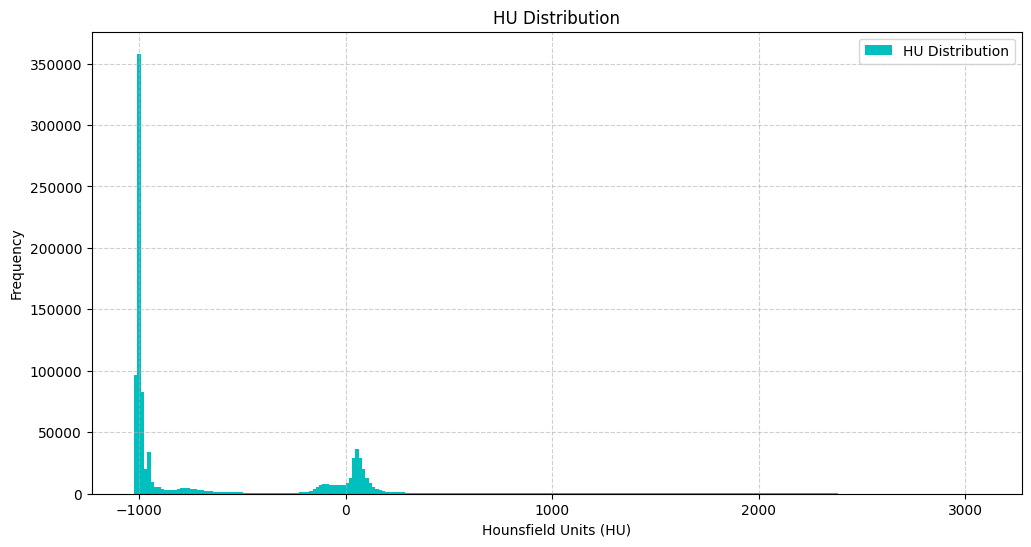

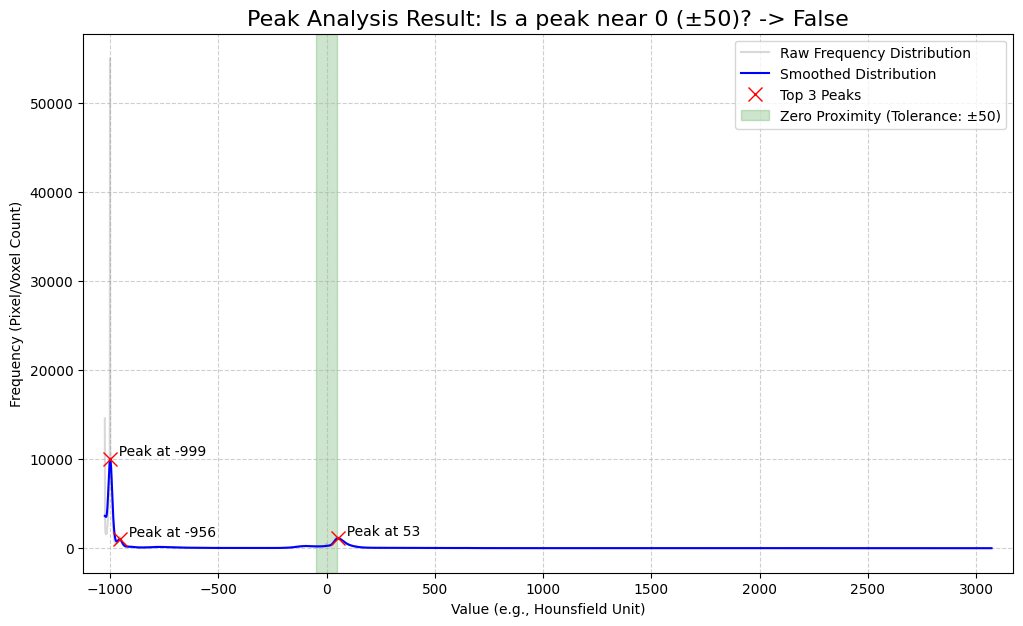

False


interactive(children=(IntSlider(value=174, description='slice_index', max=348), FloatSlider(value=0.0, descrip…

In [44]:
disp_dist_3d_raw(c2_df.iloc[random.randint(0,len(c2_df))]['scan_id'],do_hu=False) # -1000, -2000

(569, 512, 512)


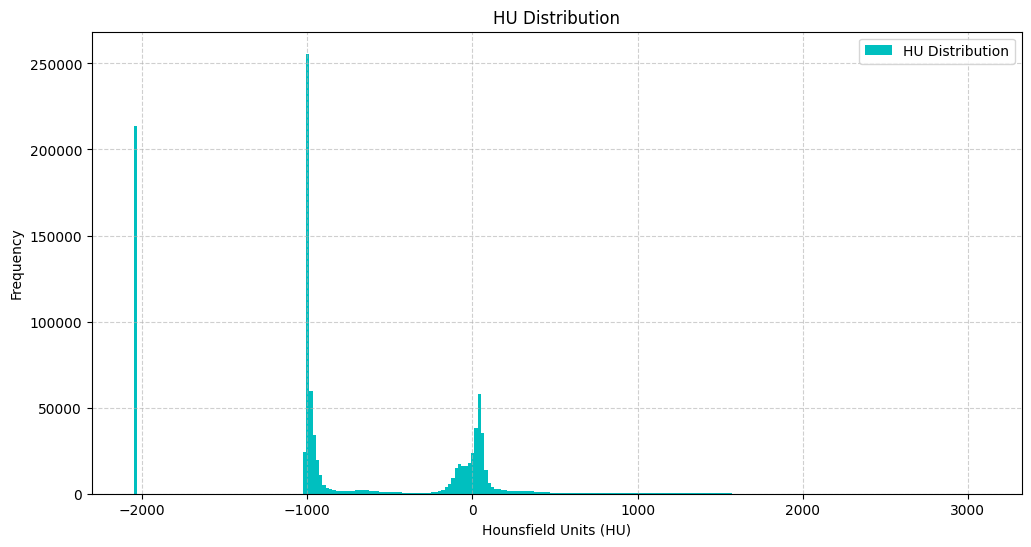

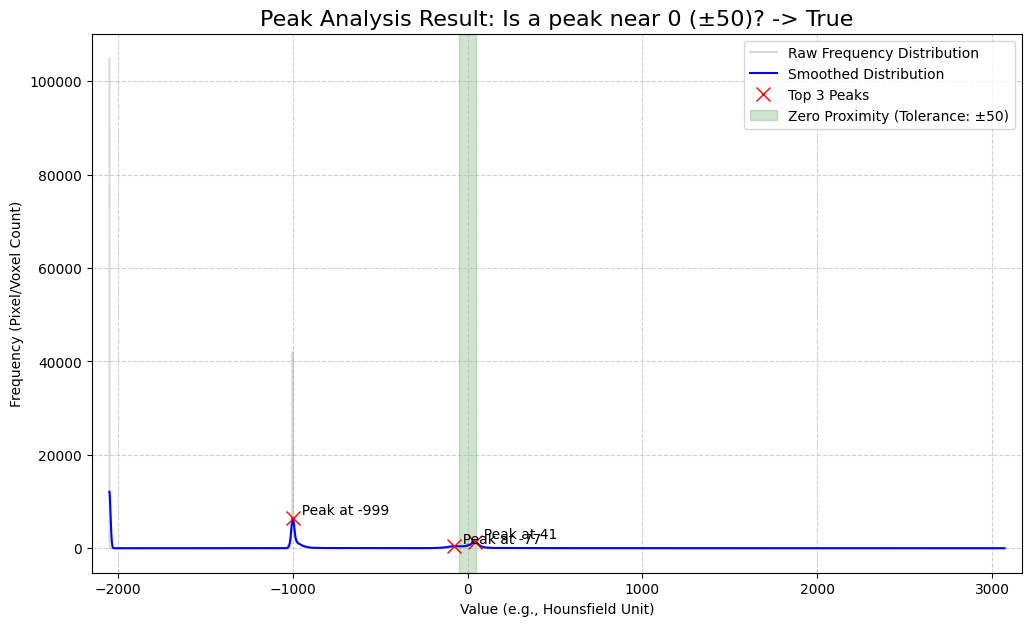

True


interactive(children=(IntSlider(value=284, description='slice_index', max=568), FloatSlider(value=0.0, descrip…

In [45]:
disp_dist_3d_raw(c3_df.iloc[random.randint(0,len(c3_df))]['scan_id'],do_hu=False) #-1000 -2000 -4000w

(507, 512, 512)


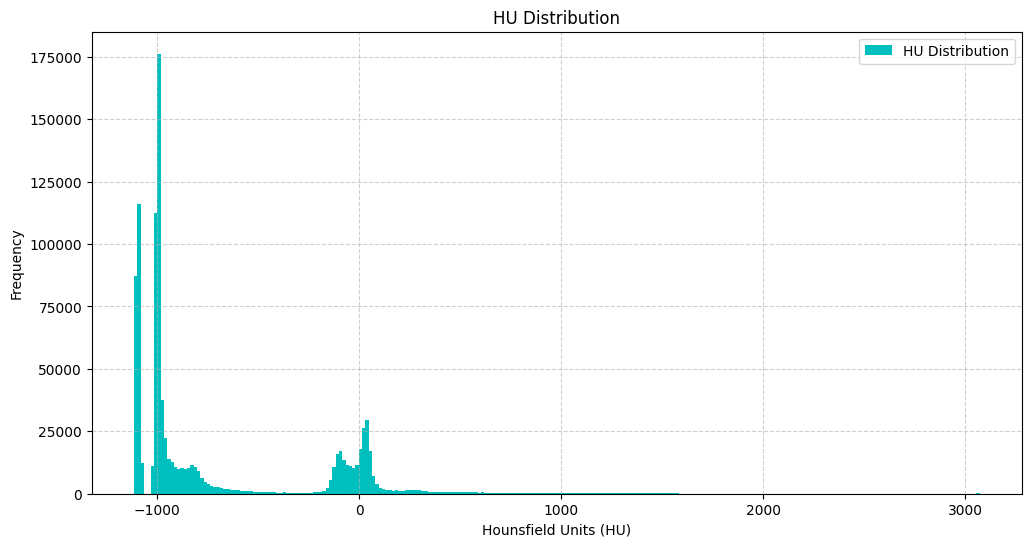

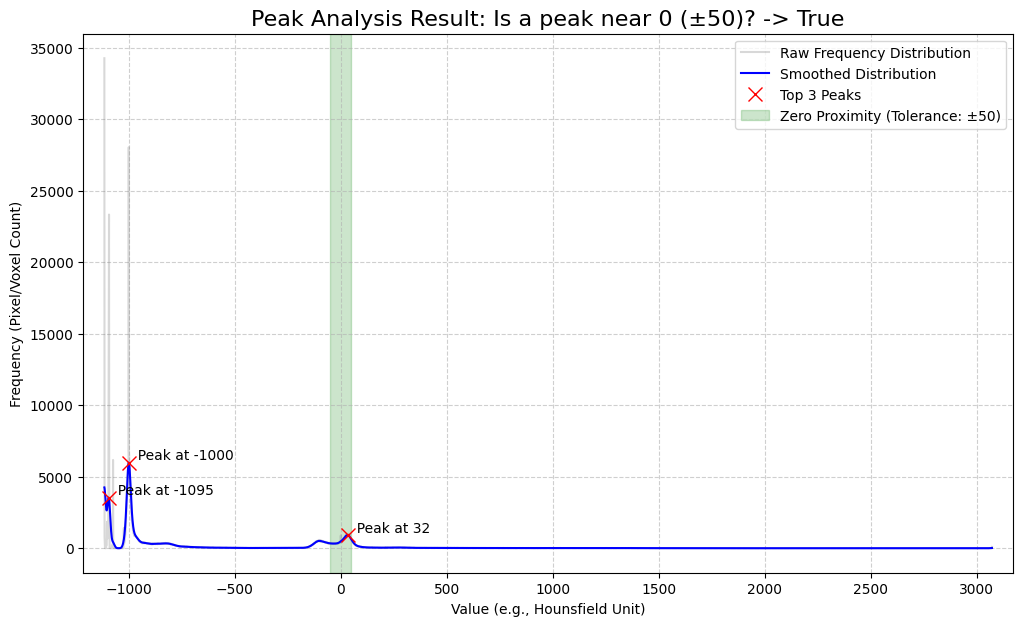

True


interactive(children=(IntSlider(value=253, description='slice_index', max=506), FloatSlider(value=0.0, descrip…

In [46]:
disp_dist_3d_raw(ou_df.iloc[random.randint(0,len(ou_df))]['scan_id'],do_hu=False) # 0 -1000

In [159]:
final_df_1k = pd.concat([c2_df,c3_df],ignore_index=True)
final_df_1k

,scan_id,p1_loc,p1_height,p1_prom,p1_width,p1_mean,p1_std,p2_loc,p2_height,p2_prom,p2_width,p2_mean,p2_std
0,1.2.826.0.1.3680043.8.498.10021411248005513321...,-977.5,1.005358e+06,9.970123e+05,11.238032,-986.182334,39.097504,-1112.5,176944.539177,69411.661686,8.446562,-1049.288096,57.749610
1,1.2.826.0.1.3680043.8.498.10030095840917973694...,-982.5,1.771857e+06,1.754607e+06,12.780025,-997.074576,46.281177,-1112.5,516559.604821,155875.731920,8.268561,-1052.853113,56.263220
2,1.2.826.0.1.3680043.8.498.10170698207397181808...,-972.5,8.832386e+05,8.674174e+05,14.603770,-988.077592,51.837718,-1122.5,550300.098087,274913.675492,9.926342,-1091.429745,52.692393
3,1.2.826.0.1.3680043.8.498.10242740813399049394...,-982.5,4.974473e+05,4.896361e+05,14.155359,-1010.341687,55.483726,-1107.5,377388.212016,168951.721323,9.464009,-1066.769036,55.016595
4,1.2.826.0.1.3680043.8.498.10277444113543832445...,-972.5,8.759659e+05,8.528750e+05,13.217411,-986.579904,48.775647,-1127.5,525597.460668,311298.270929,10.097067,-1100.116533,52.313951
...,...,...,...,...,...,...,...,...,...,...,...,...,...
223,1.2.826.0.1.3680043.8.498.17451723674143331506...,-977.5,1.114339e+06,1.103443e+06,12.725880,-987.831488,43.835829,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
224,1.2.826.0.1.3680043.8.498.17542222797476785325...,-977.5,2.287242e+06,2.272694e+06,11.100929,-984.914080,38.517269,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
225,1.2.826.0.1.3680043.8.498.17759831778622575514...,-977.5,1.576585e+06,1.552175e+06,13.687025,-986.062874,48.145346,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
226,1.2.826.0.1.3680043.8.498.17874140688479995306...,-982.5,9.552439e+05,9.509919e+05,12.377680,-989.311986,36.686399,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


In [163]:
final_df_0 = pd.concat([c1_df,ou_df],ignore_index=True)
final_df_0

,scan_id,p1_loc,p1_height,p1_prom,p1_width,p1_mean,p1_std,p2_loc,p2_height,p2_prom,p2_width,p2_mean,p2_std
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,-997.5,4.380303e+06,4.380302e+06,9.677320,-997.419490,17.041129,47.5,1.101337e+06,1.094576e+06,13.661741,42.471987,40.583496
1,1.2.826.0.1.3680043.8.498.10014757658335054766...,-992.5,1.082734e+07,1.082700e+07,12.315600,-981.431342,25.136879,42.5,2.272503e+06,2.235888e+06,14.343102,20.190495,52.708342
2,1.2.826.0.1.3680043.8.498.10022796280698534221...,-997.5,1.218204e+07,1.218203e+07,8.380299,-991.341896,19.909957,42.5,2.035701e+06,2.014665e+06,12.865289,27.227085,48.483231
3,1.2.826.0.1.3680043.8.498.10034081836061566510...,-997.5,9.756147e+05,9.756147e+05,8.262859,-996.924432,16.770497,67.5,3.297362e+05,3.282799e+05,12.059719,61.932017,41.772262
4,1.2.826.0.1.3680043.8.498.10035643165968342618...,-1002.5,2.968190e+06,2.968190e+06,9.431203,-983.621235,31.576028,42.5,7.274825e+05,7.173272e+05,12.473340,34.472649,43.961330
...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,1.2.826.0.1.3680043.8.498.13357449270526786778...,57.5,3.609648e+05,3.609648e+05,10.120685,55.724010,38.220175,-997.5,2.702187e+05,2.686676e+05,8.585596,-992.114468,27.329452
342,1.2.826.0.1.3680043.8.498.13363897289235267814...,2.5,3.141845e+05,3.141823e+05,8.260043,26.048621,39.437271,-992.5,2.125801e+05,2.106920e+05,9.703632,-989.211340,27.878704
343,1.2.826.0.1.3680043.8.498.17677548211553545296...,2.5,2.639065e+05,2.639026e+05,7.868326,18.144098,34.306538,-992.5,1.393454e+05,1.384078e+05,13.105254,-969.735001,34.971820
344,1.2.826.0.1.3680043.8.498.18010503800240053656...,-997.5,6.796223e+06,6.796154e+06,8.398506,-1026.850899,55.830371,-1097.5,3.721453e+06,3.469656e+06,8.282573,-1036.039754,49.174865


# clustering

In [96]:
import pandas as pd
import seaborn as sns

In [2]:
df_peak_feat = pd.read_csv('scan_peak_features.csv')
df_peak_feat

,scan_id,p1_loc,p1_height,p1_prom,p1_width,p1_mean,p1_std,p2_loc,p2_height,p2_prom,...,p3_prom,p3_width,p3_mean,p3_std,p4_loc,p4_height,p4_prom,p4_width,p4_mean,p4_std
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,-997.5,4.380303e+06,4.380302e+06,9.677320,-997.419490,17.041129,47.5,1.101337e+06,1.094576e+06,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,1.2.826.0.1.3680043.8.498.10014757658335054766...,-992.5,1.082734e+07,1.082700e+07,12.315600,-981.431342,25.136879,42.5,2.272503e+06,2.235888e+06,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,1.2.826.0.1.3680043.8.498.10021411248005513321...,-977.5,1.005358e+06,9.970123e+05,11.238032,-986.182334,39.097504,-1112.5,1.769445e+05,6.941166e+04,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,1.2.826.0.1.3680043.8.498.10022796280698534221...,-997.5,1.218204e+07,1.218203e+07,8.380299,-991.341896,19.909957,42.5,2.035701e+06,2.014665e+06,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,1.2.826.0.1.3680043.8.498.10030095840917973694...,-982.5,1.771857e+06,1.754607e+06,12.780025,-997.074576,46.281177,-1112.5,5.165596e+05,1.558757e+05,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,1.2.826.0.1.3680043.8.498.18053293559305998192...,-997.5,1.031623e+06,1.031616e+06,8.391892,-992.440734,23.982944,62.5,3.185365e+05,3.139449e+05,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
570,1.2.826.0.1.3680043.8.498.18104210064643499679...,7.5,2.431543e+06,2.431543e+06,9.502689,5.592401,18.508897,-497.5,1.470521e+06,1.470518e+06,...,333551.021686,7.090283,-999.974872,0.156513,0.0,0.0,0.0,0.0,0.0,0.0
571,1.2.826.0.1.3680043.8.498.18108212083513041239...,-997.5,1.345945e+07,1.345921e+07,8.797491,-990.014699,23.957295,42.5,2.325023e+06,2.276962e+06,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
572,1.2.826.0.1.3680043.8.498.18223248049712532965...,-997.5,5.420182e+06,5.420182e+06,9.498870,-984.518409,26.150060,37.5,1.385515e+06,1.375477e+06,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [70]:
df_peak_feat_t3 = df_peak_feat.copy().drop(['p4_loc','p4_height','p4_prom','p4_width','p4_mean','p4_std','p3_loc','p3_height','p3_prom','p3_width','p3_mean','p3_std'],axis=1)
df_peak_feat_t3[df_peak_feat_t3['p2_loc']!=00]

,scan_id,p1_loc,p1_height,p1_prom,p1_width,p1_mean,p1_std,p2_loc,p2_height,p2_prom,p2_width,p2_mean,p2_std
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,-997.5,4.380303e+06,4.380302e+06,9.677320,-997.419490,17.041129,47.5,1.101337e+06,1.094576e+06,13.661741,42.471987,40.583496
1,1.2.826.0.1.3680043.8.498.10014757658335054766...,-992.5,1.082734e+07,1.082700e+07,12.315600,-981.431342,25.136879,42.5,2.272503e+06,2.235888e+06,14.343102,20.190495,52.708342
2,1.2.826.0.1.3680043.8.498.10021411248005513321...,-977.5,1.005358e+06,9.970123e+05,11.238032,-986.182334,39.097504,-1112.5,1.769445e+05,6.941166e+04,8.446562,-1049.288096,57.749610
3,1.2.826.0.1.3680043.8.498.10022796280698534221...,-997.5,1.218204e+07,1.218203e+07,8.380299,-991.341896,19.909957,42.5,2.035701e+06,2.014665e+06,12.865289,27.227085,48.483231
4,1.2.826.0.1.3680043.8.498.10030095840917973694...,-982.5,1.771857e+06,1.754607e+06,12.780025,-997.074576,46.281177,-1112.5,5.165596e+05,1.558757e+05,8.268561,-1052.853113,56.263220
...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,1.2.826.0.1.3680043.8.498.18053293559305998192...,-997.5,1.031623e+06,1.031616e+06,8.391892,-992.440734,23.982944,62.5,3.185365e+05,3.139449e+05,11.760368,56.079944,43.899867
570,1.2.826.0.1.3680043.8.498.18104210064643499679...,7.5,2.431543e+06,2.431543e+06,9.502689,5.592401,18.508897,-497.5,1.470521e+06,1.470518e+06,7.090276,-499.981534,0.262572
571,1.2.826.0.1.3680043.8.498.18108212083513041239...,-997.5,1.345945e+07,1.345921e+07,8.797491,-990.014699,23.957295,42.5,2.325023e+06,2.276962e+06,18.859860,24.380557,54.200722
572,1.2.826.0.1.3680043.8.498.18223248049712532965...,-997.5,5.420182e+06,5.420182e+06,9.498870,-984.518409,26.150060,37.5,1.385515e+06,1.375477e+06,9.629565,30.024171,37.894075


In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
import os

In [80]:
MIN_PTS = 24

In [81]:
features_for_clustering = df_peak_feat_t3.drop('scan_id', axis=1)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_clustering)

In [82]:
neighbors = NearestNeighbors(n_neighbors=MIN_PTS)
neighbors_fit = neighbors.fit(features_scaled)
distances, indices = neighbors_fit.kneighbors(features_scaled)

--> Please inspect the plot to find the 'elbow'. This is your optimal 'eps' value.
--> Close the plot window to continue the script.


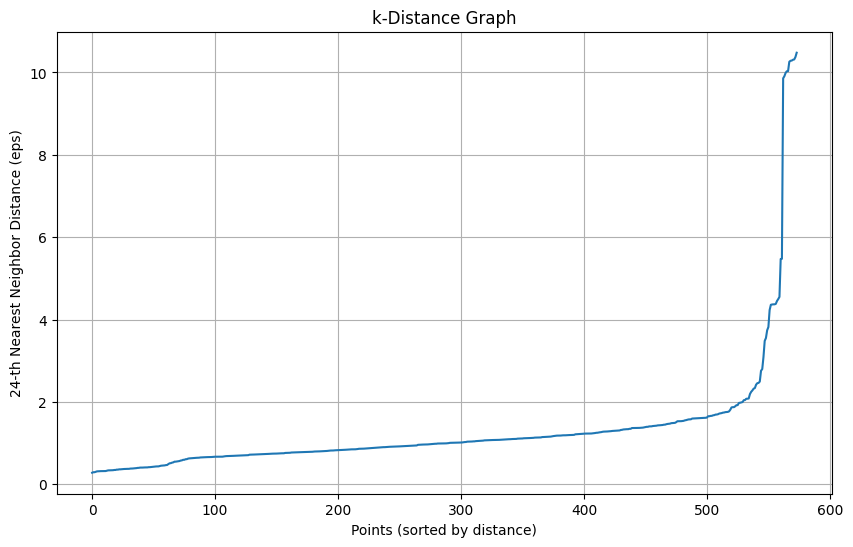

In [83]:
sorted_distances = np.sort(distances[:, MIN_PTS-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(sorted_distances)
plt.title('k-Distance Graph')
plt.xlabel('Points (sorted by distance)')
plt.ylabel(f'{MIN_PTS}-th Nearest Neighbor Distance (eps)')
plt.grid(True)
print("--> Please inspect the plot to find the 'elbow'. This is your optimal 'eps' value.")
print("--> Close the plot window to continue the script.")
plt.show()

In [84]:
EPS = 2

In [85]:
dbscan = DBSCAN(eps=EPS, min_samples=MIN_PTS)
cluster_labels = dbscan.fit_predict(features_scaled)

df_peak_feat_t3['cluster'] = cluster_labels

n_clusters_found = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_outliers_found = np.sum(cluster_labels == -1)
print(f"DBSCAN finished. Found {n_clusters_found} clusters and {n_outliers_found} outliers.")

DBSCAN finished. Found 3 clusters and 27 outliers.


In [86]:
print("\nStep 5: Saving clustered original histograms...")
output_dir = 'scan_clusters_dbscan_t2'
os.makedirs(output_dir, exist_ok=True)

for cluster_id in sorted(set(cluster_labels)):
    df_cluster = df_peak_feat_t3[df_peak_feat_t3['cluster'] == cluster_id]
    
    if cluster_id == -1:
        filename = 'outliers_data.csv'
        print(f"Outliers: Found {len(df_cluster)} samples. Saved to '{os.path.join(output_dir, filename)}'")
    else:
        filename = f'cluster_{cluster_id}_data.csv'
        print(f"Cluster {cluster_id}: Found {len(df_cluster)} samples. Saved to '{os.path.join(output_dir, filename)}'")
        
    df_cluster.drop('cluster', axis=1).to_csv(os.path.join(output_dir, filename), index=False)


Step 5: Saving clustered original histograms...
Outliers: Found 27 samples. Saved to 'scan_clusters_dbscan_t2\outliers_data.csv'
Cluster 0: Found 319 samples. Saved to 'scan_clusters_dbscan_t2\cluster_0_data.csv'
Cluster 1: Found 112 samples. Saved to 'scan_clusters_dbscan_t2\cluster_1_data.csv'
Cluster 2: Found 116 samples. Saved to 'scan_clusters_dbscan_t2\cluster_2_data.csv'


In [117]:
df_peak_feat_t3['cluster'].value_counts()

cluster
 0    319
 2    116
 1    112
-1     27
Name: count, dtype: int64

<Axes: xlabel='p1_mean', ylabel='p2_mean'>

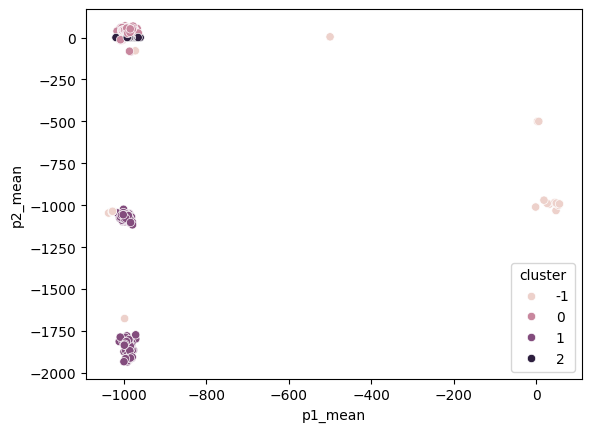

In [164]:
sns.scatterplot(data=df_peak_feat_t3, x='p1_mean', y='p2_mean', hue='cluster')

In [137]:
output_dir =  'scan_clusters_dbscan'
c1_o_df = pd.read_csv(f'{output_dir}/cluster_0_data.csv')
c2_o_df = pd.read_csv(f'{output_dir}/cluster_1_data.csv')
c3_o_df = pd.read_csv(f'{output_dir}/cluster_2_data.csv')
c4_o_df = pd.read_csv(f'{output_dir}/cluster_3_data.csv')
c5_o_df = pd.read_csv(f'{output_dir}/cluster_4_data.csv')
ou_o_df = pd.read_csv(f'{output_dir}/outliers_data.csv')

<Axes: ylabel='3'>

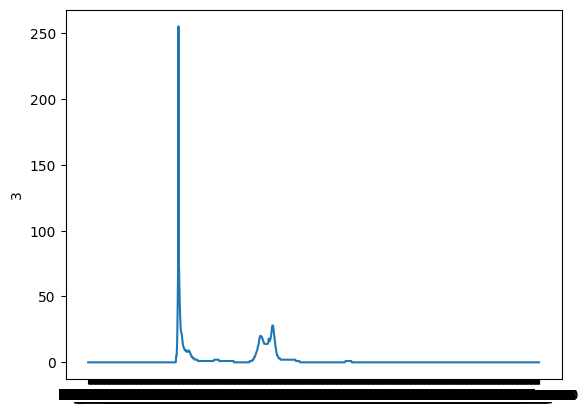

In [196]:
sns.lineplot(ou_o_df.drop('scan_id', axis=1).iloc[random.randint(0,len(ou_o_df))].pipe(lambda s: pd.cut(s, bins=256, labels=False)))

In [20]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def is_zero_a_top_peak(data, sigma=7, prominence=1, num_peaks=3, tolerance=50, show_plot=False):
    """
    Analyzes numerical data (e.g., from an image) to determine if a top peak is near zero.

    The process is as follows:
    1. Flattens the input data (if it's multi-dimensional) and samples it if too large.
    2. Creates a frequency distribution (histogram) of the integer data.
    3. Applies a Gaussian blur to smooth the distribution.
    4. Finds the top N (default 3) peaks in the smoothed data.
    5. Checks if any top peak is within a specified 'tolerance' of 0.

    Args:
        data (np.ndarray): A numpy array of numbers.
        sigma (float): The standard deviation for the Gaussian kernel, controlling
                       the amount of smoothing. Higher values are needed for noisy data.
        prominence (float): The required prominence of peaks.
        num_peaks (int): The number of top peaks to consider.
        tolerance (int): The distance from zero to check for peaks (e.g., a tolerance
                         of 50 checks the range [-50, 50]).
        show_plot (bool): If True, a plot visualizing the process will be displayed.

    Returns:
        bool: True if a top N peak is within the tolerance of zero, False otherwise.
    """
    # --- 1. Pre-processing and Input Validation ---
    if not isinstance(data, np.ndarray) or data.size == 0:
        print("Warning: Input data is empty or not a numpy array.")
        return False

    # Flatten the array for processing (e.g., from a 3D image volume)
    flat_data = data.flatten()

    # If the dataset is very large, take a random sample to speed up processing
    # This is a good strategy for large images where the distribution is stable.
    if flat_data.size > 500_000:
        flat_data = np.random.choice(flat_data, size=500_000, replace=False)

    # np.bincount requires non-negative integers. We will cast and shift the data.
    flat_data = np.round(flat_data).astype(int)

    # --- 2. Create Frequency Distribution ---
    min_val = flat_data.min()
    shifted_data = flat_data - min_val
    
    # Use bincount for a fast and accurate frequency count
    freq_dist = np.bincount(shifted_data)
    original_values = np.arange(min_val, min_val + len(freq_dist))

    # --- 3. Smooth the Distribution with Gaussian Blur ---
    smoothed_freq = gaussian_filter1d(freq_dist.astype(float), sigma=sigma)

    # --- 4. Find Top N Peaks ---
    indices, _ = find_peaks(smoothed_freq, prominence=prominence)
    
    if len(indices) == 0:
        print("No peaks found.")
        if show_plot:
            visualize_peak_finding(original_values, freq_dist, smoothed_freq, [], [], tolerance, False)
        return False

    heights = smoothed_freq[indices]
    sorted_indices_by_height = indices[np.argsort(heights)[::-1]]
    top_peak_indices = sorted_indices_by_height[:num_peaks]
    top_peak_values = original_values[top_peak_indices]

    # --- 5. Check if a peak is NEAR zero ---
    result = any(abs(val) <= tolerance for val in top_peak_values)
    # --- 6. (Optional) Visualization ---
    if show_plot:
        visualize_peak_finding(original_values, freq_dist, smoothed_freq, top_peak_indices, top_peak_values, tolerance, result)

    return result


def visualize_peak_finding(x_values, raw_freq, smoothed_freq, top_peak_indices, top_peak_values, tolerance, result):
    """A helper function to plot the analysis steps."""
    plt.figure(figsize=(12, 7))
    
    plt.plot(x_values, raw_freq, alpha=0.3, label='Raw Frequency Distribution', color='gray')
    plt.plot(x_values, smoothed_freq, label='Smoothed Distribution', color='blue')
    
    if len(top_peak_indices) > 0:
        plt.plot(x_values[top_peak_indices], smoothed_freq[top_peak_indices], "x", color='red', markersize=10, label=f'Top {len(top_peak_values)} Peaks')

    plt.axvspan(-tolerance, tolerance, color='green', alpha=0.2, label=f'Zero Proximity (Tolerance: ±{tolerance})')
    
    plt.title(f"Peak Analysis Result: Is a peak near 0 (±{tolerance})? -> {result}", fontsize=16)
    plt.xlabel("Value (e.g., Hounsfield Unit)")
    plt.ylabel("Frequency (Pixel/Voxel Count)")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    for val, idx in zip(top_peak_values, top_peak_indices):
        plt.text(val, smoothed_freq[idx], f'  Peak at {val}', verticalalignment='bottom')
        
    plt.legend()
    # Limit x-axis for better readability if the range is huge (common with HU units)
    if x_values.max() - x_values.min() > 2000:
        plt.xlim(x_values.min() - 100, x_values.max() + 100)

    plt.show()

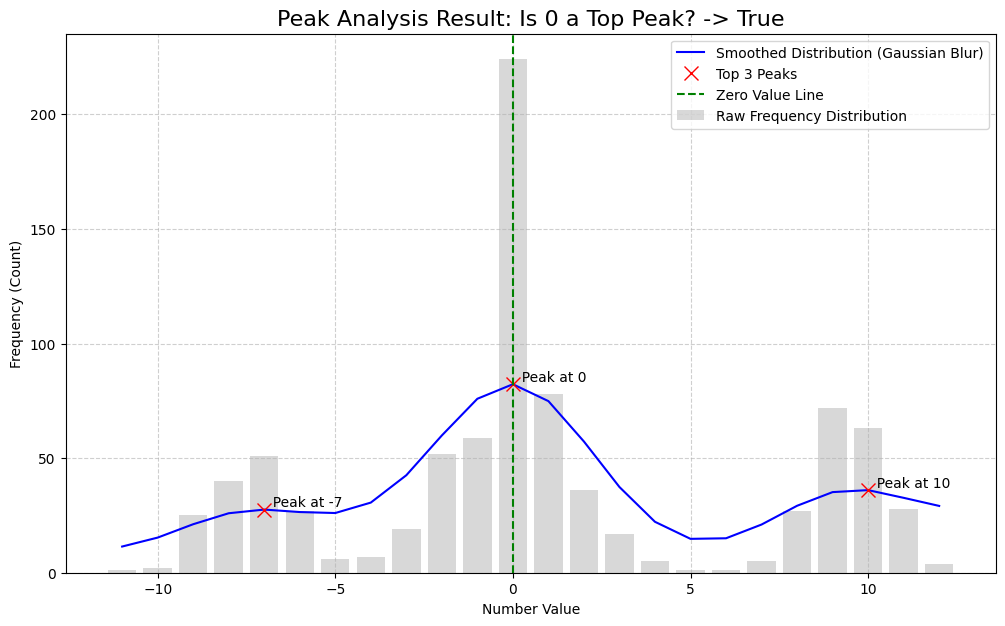

Data 1: Is 0 a top 3 peak? -> True


In [ ]:
# Data where 0 is the most frequent number, forming a clear peak.
data1 = list(np.random.normal(0, 2, 500).astype(int)) + \
        list(np.random.normal(10, 1, 200).astype(int)) + \
        list(np.random.normal(-8, 1, 150).astype(int))

print(f"Data 1: Is 0 a top 3 peak? -> {is_zero_a_top_peak(, sigma=2, show_plot=True)}")

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def is_zero_a_top_peak(data, sigma=7, prominence=1, num_peaks=3, tolerance=50):
    if not isinstance(data, np.ndarray) or data.size == 0:
        print("Warning: Input data is empty or not a numpy array.")
        return False

    flat_data = data.flatten()
    if flat_data.size > 500_000:
        flat_data = np.random.choice(flat_data, size=500_000, replace=False)

    flat_data = np.round(flat_data).astype(int)

    min_val = flat_data.min()
    shifted_data = flat_data - min_val
    
    freq_dist = np.bincount(shifted_data)
    original_values = np.arange(min_val, min_val + len(freq_dist))

    smoothed_freq = gaussian_filter1d(freq_dist.astype(float), sigma=sigma)

    indices, _ = find_peaks(smoothed_freq, prominence=prominence)
    
    if len(indices) == 0:
        print("No peaks found.")
        return False

    heights = smoothed_freq[indices]
    sorted_indices_by_height = indices[np.argsort(heights)[::-1]]
    top_peak_indices = sorted_indices_by_height[:num_peaks]
    top_peak_values = original_values[top_peak_indices]

    # --- 5. Check if a peak is NEAR zero ---
    result = any(abs(val) <= tolerance for val in top_peak_values)

    return result
